In [ ]:
!pip install kaggle

from google.colab import files
import os

uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list


Saving archive(6).zip to archive(6) (1).zip
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub
!kaggle datasets download -d nurasssyl/kazakhstan-population-by-gender-and-locality-2024

path = kagglehub.dataset_download("nurasssyl/kazakhstan-population-by-gender-and-locality-2024")
print("Path to dataset files:", path)

Dataset URL: https://www.kaggle.com/datasets/nurasssyl/kazakhstan-population-by-gender-and-locality-2024
License(s): CC-BY-NC-SA-4.0
kazakhstan-population-by-gender-and-locality-2024.zip: Skipping, found more recently modified local copy (use --force to force download)
Using Colab cache for faster access to the 'kazakhstan-population-by-gender-and-locality-2024' dataset.
Path to dataset files: /kaggle/input/kazakhstan-population-by-gender-and-locality-2024


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "Population of the Republic of Kazakhstan by gender and type of locality (as of July 1 2024).csv")

df = pd.read_csv(file_path)

# CHECKING TABLE
print(df.head())


  Districts (adm2 level) Total population      men    women urban_population  \
0             Semei с.а.          311,694  149,017  162,677          311,604   
1         Кurchatov с.а.           10,217    4,987    5,230           10,217   
2          Abai district           13,756    6,906    6,850                -   
3        Aksuat district           19,128    9,826    9,302                -   
4         Ayagoz distict           64,968   32,699   32,269           41,820   

  urban_population_men urban_population_women rural_population  \
0              148,967                162,637               90   
1                4,987                  5,230                -   
2                    -                      -           13,756   
3                    -                      -           19,128   
4               20,717                 21,103           23,148   

  rural_population_men rural_population_women  
0                   50                     40  
1                    -    

In [ ]:
print(df.info())
df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].str.replace(",", "").astype(int)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Districts (adm2 level)  227 non-null    object
 1   Total population        227 non-null    object
 2   men                     227 non-null    object
 3   women                   227 non-null    object
 4   urban_population        227 non-null    object
 5   urban_population_men    227 non-null    object
 6   urban_population_women  227 non-null    object
 7   rural_population        227 non-null    object
 8   rural_population_men    227 non-null    object
 9   rural_population_women  227 non-null    object
dtypes: object(10)
memory usage: 17.9+ KB
None


In [ ]:
df_clean["urban_ratio"] = df_clean["urban_population"] / df_clean["Total population"]
df_clean["target"] = (df_clean["urban_ratio"] > 0.5).astype(int)


In [ ]:
X = df_clean[["men", "women", "urban_population", "rural_population"]]
y = df_clean["target"]

In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].str.replace(",", "").astype(int)

df_clean["urban_ratio"] = df_clean["urban_population"] / df_clean["Total population"]
df_clean["target"] = (df_clean["urban_ratio"] > 0.5).astype(int)

# === X and Y ===
X = df_clean[["men", "women", "urban_population", "rural_population"]]
y = df_clean["target"]


results = []

# MODELS
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=0),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# (IT IS JUST FOR VISUALIUATION)
splits = [(0.7,0.3), (0.8,0.2), (0.6,0.4), (0.75,0.25), (0.85,0.15)]

for i, (train_size, test_size) in enumerate(splits, start=1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, stratify=y, random_state=i
    )

    # Scaling data for KNN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for name, model in models.items():
        if name == "KNN":
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            "Iteration": i,
            "Features": X.shape[1],
            "Classes": len(np.unique(y)),
            "Train/Test Split": f"{int(train_size*100)}/{int(test_size*100)}",
            "Model": name,
            "Accuracy": round(acc,3),
            "Precision": round(prec,3),
            "Recall": round(rec,3),
            "F1": round(f1,3)
        })

# Result Table
results_df = pd.DataFrame(results)
print(results_df)


    Iteration  Features  Classes Train/Test Split          Model  Accuracy  \
0           1         4        2            70/30  Decision Tree     0.942   
1           1         4        2            70/30  Random Forest     0.942   
2           1         4        2            70/30            KNN     0.913   
3           2         4        2            80/20  Decision Tree     0.891   
4           2         4        2            80/20  Random Forest     0.891   
5           2         4        2            80/20            KNN     0.913   
6           3         4        2            60/40  Decision Tree     0.978   
7           3         4        2            60/40  Random Forest     0.978   
8           3         4        2            60/40            KNN     0.967   
9           4         4        2            75/25  Decision Tree     0.965   
10          4         4        2            75/25  Random Forest     1.000   
11          4         4        2            75/25            KNN

In [ ]:
pivot_df = results_df.pivot_table(
    index=['Model', 'Iteration', 'Train/Test Split'],
    values=['Accuracy', 'Precision', 'Recall', 'F1'],
    aggfunc='first'
).reset_index()

pivot_df = pivot_df.rename(columns={
    'Model': 'Algorithm',
    'Iteration': 'Number of iterations',
    'Train/Test Split': 'Train Size, % / Test size, %'
})

pivot_df['Number of features'] = X.shape[1]
pivot_df['Number of targets'] = len(np.unique(y))

final_table = pivot_df[[
    'Algorithm', 'Number of iterations', 'Number of features', 'Number of targets',
    'Train Size, % / Test size, %', 'Accuracy', 'Precision', 'Recall', 'F1'
]]

for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    final_table[col] = final_table[col].apply(lambda x: f'{x:.3f}')

print("Table 1 - Results of Experiments")
print(final_table.to_string(index=False))

Table 1 - Results of Experiments
    Algorithm  Number of iterations  Number of features  Number of targets Train Size, % / Test size, % Accuracy Precision Recall    F1
Decision Tree                     1                   4                  2                        70/30    0.942     0.909  0.909 0.909
Decision Tree                     2                   4                  2                        80/20    0.891     0.857  0.800 0.828
Decision Tree                     3                   4                  2                        60/40    0.978     1.000  0.933 0.966
Decision Tree                     4                   4                  2                        75/25    0.965     0.947  0.947 0.947
Decision Tree                     5                   4                  2                        85/15    0.943     1.000  0.818 0.900
          KNN                     1                   4                  2                        70/30    0.913     1.000  0.727 0.842
          KNN  

In [ ]:
# ===== Article-ready figure style =====
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style='whitegrid')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True
})

def finalize_figure(filename=None):
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()


In [ ]:
# Figure 2: accuracy comparison
model_stats = results_df.groupby('Model')['Accuracy'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(11, 7))
bars = plt.bar(
    model_stats['Model'],
    model_stats['mean'],
    yerr=model_stats['std'],
    capsize=6,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.ylabel('Accuracy (mean ± standard deviation)')
plt.xlabel('Algorithm')
plt.ylim(0, 1.08)
finalize_figure('figure_2_accuracy_comparison.png')


In [ ]:
# Figure 3: boxplots of evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, metric in enumerate(metrics):
    ax = axes[i // 2, i % 2]
    ax.boxplot(
        [results_df[results_df['Model'] == model][metric] for model in results_df['Model'].unique()],
        labels=results_df['Model'].unique(),
        patch_artist=False
    )
    ax.set_title(metric)
    ax.set_ylabel('Value')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_3_metrics_boxplots.png', dpi=600, bbox_inches='tight')
plt.show()


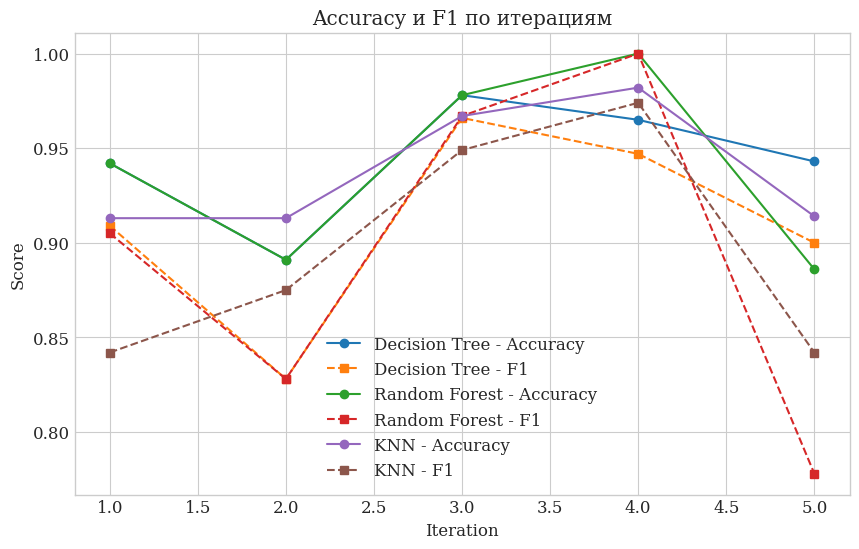

In [ ]:
plt.figure(figsize=(10,6))
for model in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model]
    plt.plot(subset["Iteration"], subset["Accuracy"], marker="o", label=f"{model} - Accuracy")
    plt.plot(subset["Iteration"], subset["F1"], marker="s", linestyle="--", label=f"{model} - F1")
plt.title("Accuracy и F1 по итерациям")
plt.xlabel("Iteration")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

Data columns: ['Districts (adm2 level)', 'Total population', 'men', 'women', 'urban_population', 'urban_population_men', 'urban_population_women', 'rural_population', 'rural_population_men', 'rural_population_women']

First 5 rows:
  Districts (adm2 level) Total population      men    women urban_population  \
0             Semei с.а.          311,694  149,017  162,677          311,604   
1         Кurchatov с.а.           10,217    4,987    5,230           10,217   
2          Abai district           13,756    6,906    6,850                -   
3        Aksuat district           19,128    9,826    9,302                -   
4         Ayagoz distict           64,968   32,699   32,269           41,820   

  urban_population_men urban_population_women rural_population  \
0              148,967                162,637               90   
1                4,987                  5,230                -   
2                    -                      -           13,756   
3                    - 

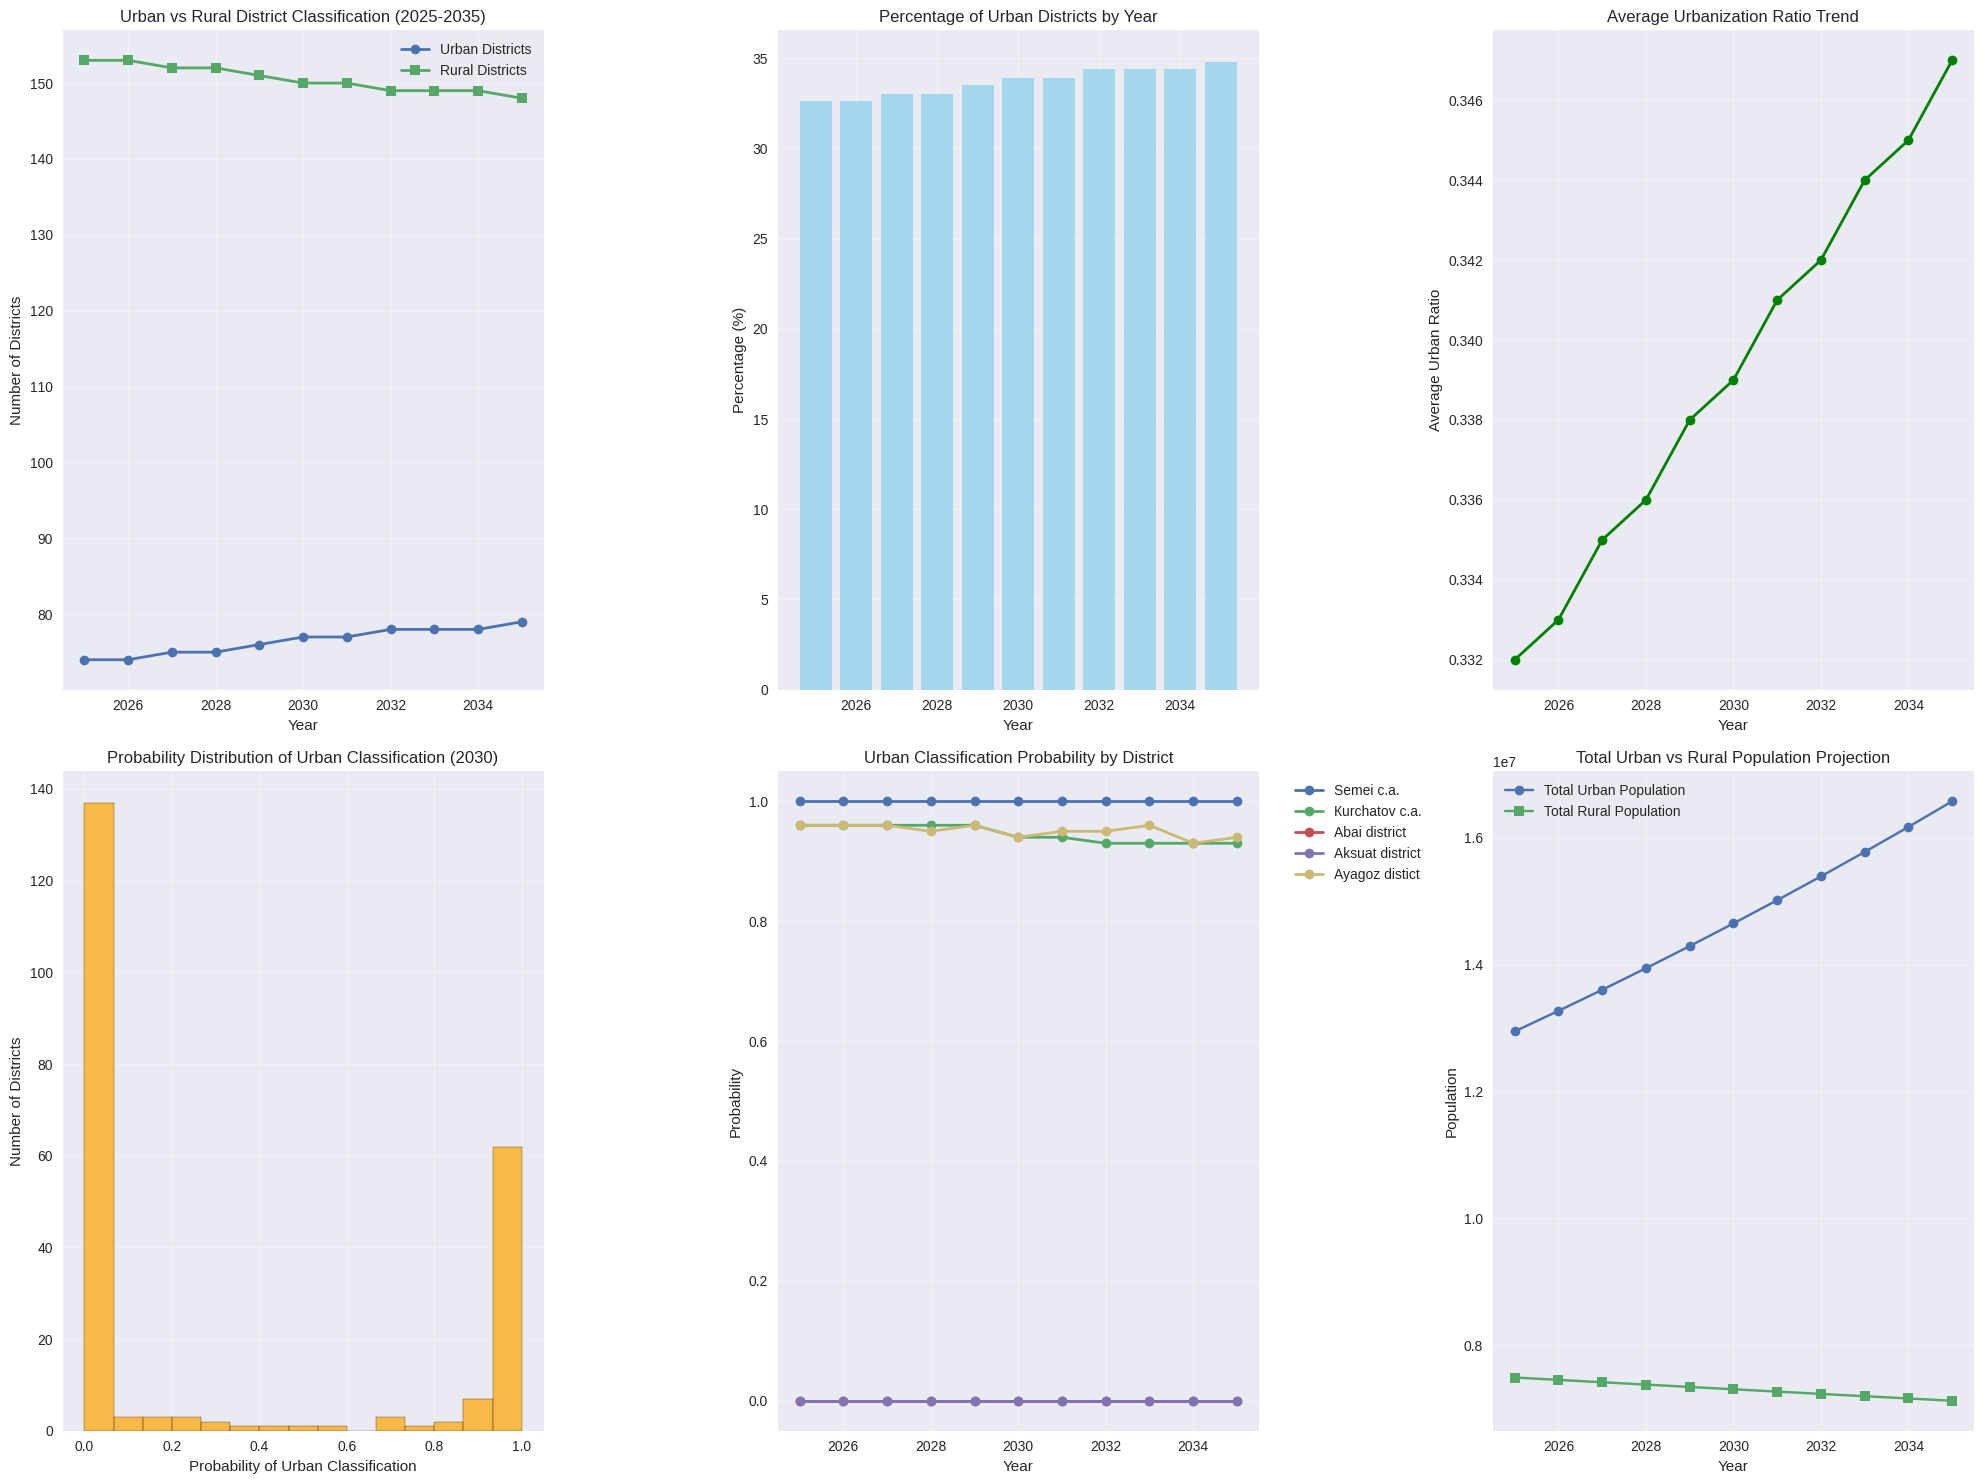


Prediction files saved:
- kz_district_urbanization_predictions_2025_2035.csv
- kz_urbanization_summary_2025_2035.csv

FINAL PREDICTION OVERVIEW
Baseline year (2024): 227 districts total
Urban districts in 2024: 74
Predicted urban districts in 2035: 79
Urbanization rate increase: 32.6% → 34.8%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



# Check data structure
print("Data columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# Data cleaning
df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:  # Skip first column (District names)
    df_clean[col] = df_clean[col].astype(str).str.replace(",", "").astype(float).astype(int)

# Calculate urban ratio and target variable
df_clean["urban_ratio"] = df_clean["urban_population"] / df_clean["Total population"]
df_clean["target"] = (df_clean["urban_ratio"] > 0.5).astype(int)

# Prepare features and target
X = df_clean[["men", "women", "urban_population", "rural_population"]]
y = df_clean["target"]

# Train models and evaluate
results = []

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=0),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

splits = [(0.7,0.3), (0.8,0.2), (0.6,0.4), (0.75,0.25), (0.85,0.15)]

for i, (train_size, test_size) in enumerate(splits, start=1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, stratify=y, random_state=i
    )

    # Scale data for KNN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for name, model in models.items():
        if name == "KNN":
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        results.append({
            "Iteration": i,
            "Train/Test Split": f"{int(train_size*100)}/{int(test_size*100)}",
            "Model": name,
            "Accuracy": round(acc,3),
            "Precision": round(prec,3),
            "Recall": round(rec,3),
            "F1": round(f1,3)
        })

# Display results
results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
print(results_df)

# =============================================================================
# PREDICTION FOR FUTURE YEARS (2025-2035)
# =============================================================================

# Train best model on full dataset
best_model = RandomForestClassifier(n_estimators=100, random_state=0)
best_model.fit(X, y)

# Create future predictions dataframe
future_years = list(range(2025, 2036))
predictions_data = []

# Population growth factors (adjustable based on demographic trends)
growth_factors = {
    'men': 1.015,        # 1.5% annual growth
    'women': 1.014,      # 1.4% annual growth
    'urban_population': 1.025,  # 2.5% annual growth (urbanization)
    'rural_population': 0.995   # 0.5% annual decline
}

# Generate predictions for each district and year
for year in future_years:
    year_predictions = []

    for idx, district_data in df_clean.iterrows():
        # Calculate years from baseline (2024)
        years_from_2024 = year - 2024

        # Project future population values
        future_features = {
            'men': district_data['men'] * (growth_factors['men'] ** years_from_2024),
            'women': district_data['women'] * (growth_factors['women'] ** years_from_2024),
            'urban_population': district_data['urban_population'] * (growth_factors['urban_population'] ** years_from_2024),
            'rural_population': district_data['rural_population'] * (growth_factors['rural_population'] ** years_from_2024)
        }

        # Prepare features for prediction
        future_X = pd.DataFrame([future_features])

        # Make prediction
        prediction = best_model.predict(future_X)[0]
        prediction_proba = best_model.predict_proba(future_X)[0]

        # Calculate future metrics
        future_total = future_features['urban_population'] + future_features['rural_population']
        future_urban_ratio = future_features['urban_population'] / future_total if future_total > 0 else 0

        year_predictions.append({
            'District': district_data.iloc[0],  # First column contains district names
            'Year': year,
            'Predicted_Class': prediction,
            'Probability_Urban': prediction_proba[1],
            'Future_Urban_Ratio': future_urban_ratio,
            'Urban_Population': future_features['urban_population'],
            'Rural_Population': future_features['rural_population'],
            'Total_Population': future_total
        })

    predictions_data.extend(year_predictions)

# Create predictions dataframe
predictions_df = pd.DataFrame(predictions_data)

# =============================================================================
# CREATE SUMMARY TABLES AND VISUALIZATIONS
# =============================================================================

# Yearly summary table
yearly_summary = predictions_df.groupby('Year').agg({
    'Predicted_Class': ['sum', 'count'],
    'Probability_Urban': 'mean',
    'Future_Urban_Ratio': 'mean'
}).round(3)

yearly_summary.columns = ['Urban_Districts', 'Total_Districts', 'Avg_Probability_Urban', 'Avg_Urban_Ratio']
yearly_summary['Urban_Percentage'] = (yearly_summary['Urban_Districts'] / yearly_summary['Total_Districts'] * 100).round(1)
yearly_summary['Rural_Districts'] = yearly_summary['Total_Districts'] - yearly_summary['Urban_Districts']

print("\n" + "="*60)
print("PREDICTION SUMMARY FOR 2025-2035")
print("="*60)
print(yearly_summary[['Urban_Districts', 'Rural_Districts', 'Urban_Percentage', 'Avg_Urban_Ratio']])

# Detailed table for specific districts
sample_districts = predictions_df['District'].unique()[:5]  # First 5 districts
sample_predictions = predictions_df[predictions_df['District'].isin(sample_districts)]

# Create pivot table for sample districts
pivot_table = sample_predictions.pivot_table(
    index='District',
    columns='Year',
    values='Predicted_Class'
)

print("\nPREDICTION TABLE FOR SAMPLE DISTRICTS (1=Urban, 0=Rural):")
print(pivot_table)

# =============================================================================
# VISUALIZATIONS
# =============================================================================

# Set style for better visuals
plt.style.use('seaborn-v0_8')
fig = plt.figure(figsize=(20, 15))

# Plot 1: Urban vs Rural districts over time
plt.subplot(2, 3, 1)
plt.plot(yearly_summary.index, yearly_summary['Urban_Districts'],
         marker='o', linewidth=2, label='Urban Districts')
plt.plot(yearly_summary.index, yearly_summary['Rural_Districts'],
         marker='s', linewidth=2, label='Rural Districts')
plt.title('Urban vs Rural District Classification (2025-2035)')
plt.xlabel('Year')
plt.ylabel('Number of Districts')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Percentage of urban districts
plt.subplot(2, 3, 2)
plt.bar(yearly_summary.index, yearly_summary['Urban_Percentage'],
        color='skyblue', alpha=0.7)
plt.title('Percentage of Urban Districts by Year')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.grid(True, alpha=0.3)

# Plot 3: Average urban ratio trend
plt.subplot(2, 3, 3)
plt.plot(yearly_summary.index, yearly_summary['Avg_Urban_Ratio'],
         marker='o', color='green', linewidth=2)
plt.title('Average Urbanization Ratio Trend')
plt.xlabel('Year')
plt.ylabel('Average Urban Ratio')
plt.grid(True, alpha=0.3)

# Plot 4: Probability distribution for 2030
plt.subplot(2, 3, 4)
year_2030_data = predictions_df[predictions_df['Year'] == 2030]
plt.hist(year_2030_data['Probability_Urban'], bins=15, alpha=0.7,
         color='orange', edgecolor='black')
plt.title('Probability Distribution of Urban Classification (2030)')
plt.xlabel('Probability of Urban Classification')
plt.ylabel('Number of Districts')
plt.grid(True, alpha=0.3)

# Plot 5: District-specific trends
plt.subplot(2, 3, 5)
for district in sample_districts:
    district_data = predictions_df[predictions_df['District'] == district]
    plt.plot(district_data['Year'], district_data['Probability_Urban'],
             marker='o', linewidth=2, label=district)

plt.title('Urban Classification Probability by District')
plt.xlabel('Year')
plt.ylabel('Probability')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Plot 6: Population growth comparison
plt.subplot(2, 3, 6)
urban_growth = predictions_df.groupby('Year')['Urban_Population'].sum()
rural_growth = predictions_df.groupby('Year')['Rural_Population'].sum()
plt.plot(urban_growth.index, urban_growth, marker='o', label='Total Urban Population')
plt.plot(rural_growth.index, rural_growth, marker='s', label='Total Rural Population')
plt.title('Total Urban vs Rural Population Projection')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# EXPORT RESULTS
# =============================================================================

# Save predictions to CSV files
predictions_df.to_csv('kz_district_urbanization_predictions_2025_2035.csv', index=False)
yearly_summary.to_csv('kz_urbanization_summary_2025_2035.csv')

print(f"\nPrediction files saved:")
print("- kz_district_urbanization_predictions_2025_2035.csv")
print("- kz_urbanization_summary_2025_2035.csv")

# Display final summary
print("\n" + "="*60)
print("FINAL PREDICTION OVERVIEW")
print("="*60)
print(f"Baseline year (2024): {len(df_clean)} districts total")
print(f"Urban districts in 2024: {df_clean['target'].sum()}")
print(f"Predicted urban districts in 2035: {yearly_summary.loc[2035, 'Urban_Districts']:.0f}")
print(f"Urbanization rate increase: {yearly_summary.loc[2025, 'Urban_Percentage']:.1f}% → {yearly_summary.loc[2035, 'Urban_Percentage']:.1f}%")

In [ ]:
# Figure 6: correlation heatmap
correlation_matrix = df_clean[['men', 'women', 'urban_population', 'rural_population', 'urban_ratio', 'target']].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    annot_kws={'size': 10},
    cmap='coolwarm',
    center=0,
    square=True,
    fmt='.3f',
    cbar_kws={'shrink': 0.85},
    linewidths=0.5,
    linecolor='white'
)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
finalize_figure('figure_6_correlation_heatmap.png')

print("""
DESCRIPTION FOR PAPER:
Figure 6 presents a correlation heatmap analyzing relationships between key demographic variables.
The visualization reveals strong positive correlations between urban population and total gender
distributions, while showing expected negative correlations with rural population measures.
The urban_ratio variable demonstrates significant predictive power for the target classification,
validating its selection as a primary feature. This correlation analysis provides crucial insights
into feature interdependencies and supports the model's feature engineering approach.
""")


In [ ]:
# Figure 7: radar chart of average model performance
from math import pi

avg_metrics = results_df.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].mean()
categories = list(avg_metrics.columns)
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for model in avg_metrics.index:
    values = avg_metrics.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
plt.ylim(0, 1)
plt.legend(loc='upper right', bbox_to_anchor=(1.18, 1.10), frameon=True)

plt.tight_layout()
plt.savefig('figure_7_radar_chart.png', dpi=600, bbox_inches='tight')
plt.show()

print('Average Performance Metrics:')
print(avg_metrics.round(3))


Laboratory work 3
Assignment Title: Predicting Total Population above the Urban and Rural area
Objective: Build a linear regression model to predict population of Urban and Rural based on their quantity.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("nurasssyl/kazakhstan-population-by-gender-and-locality-2024")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kazakhstan-population-by-gender-and-locality-2024' dataset.
Path to dataset files: /kaggle/input/kazakhstan-population-by-gender-and-locality-2024


In [ ]:
# Preparation data to the integer
df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].str.replace(",", "").astype(int)


In [ ]:
# Creating general variable as "Total Population"
df_clean["Total_population"] = df_clean["Total population"]

print("First 5 row data")
print(df_clean.head())

First 5 row data
  Districts (adm2 level)  Total population     men   women  urban_population  \
0             Semei с.а.            311694  149017  162677            311604   
1         Кurchatov с.а.             10217    4987    5230             10217   
2          Abai district             13756    6906    6850                 0   
3        Aksuat district             19128    9826    9302                 0   
4         Ayagoz distict             64968   32699   32269             41820   

   urban_population_men  urban_population_women  rural_population  \
0                148967                  162637                90   
1                  4987                    5230                 0   
2                     0                       0             13756   
3                     0                       0             19128   
4                 20717                   21103             23148   

   rural_population_men  rural_population_women  Total_population  
0                  

In [ ]:
# 2. Exploratory Data Analysis (EDA)
print("\nInformation data:")
print(df_clean.info())

print("\nDescription statistics")
print(df_clean.describe())



Information data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Districts (adm2 level)  227 non-null    object
 1   Total population        227 non-null    int64 
 2   men                     227 non-null    int64 
 3   women                   227 non-null    int64 
 4   urban_population        227 non-null    int64 
 5   urban_population_men    227 non-null    int64 
 6   urban_population_women  227 non-null    int64 
 7   rural_population        227 non-null    int64 
 8   rural_population_men    227 non-null    int64 
 9   rural_population_women  227 non-null    int64 
 10  Total_population        227 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 19.6+ KB
None

Description statistics
       Total population            men          women  urban_population  \
count        227.000000     227.000000     2

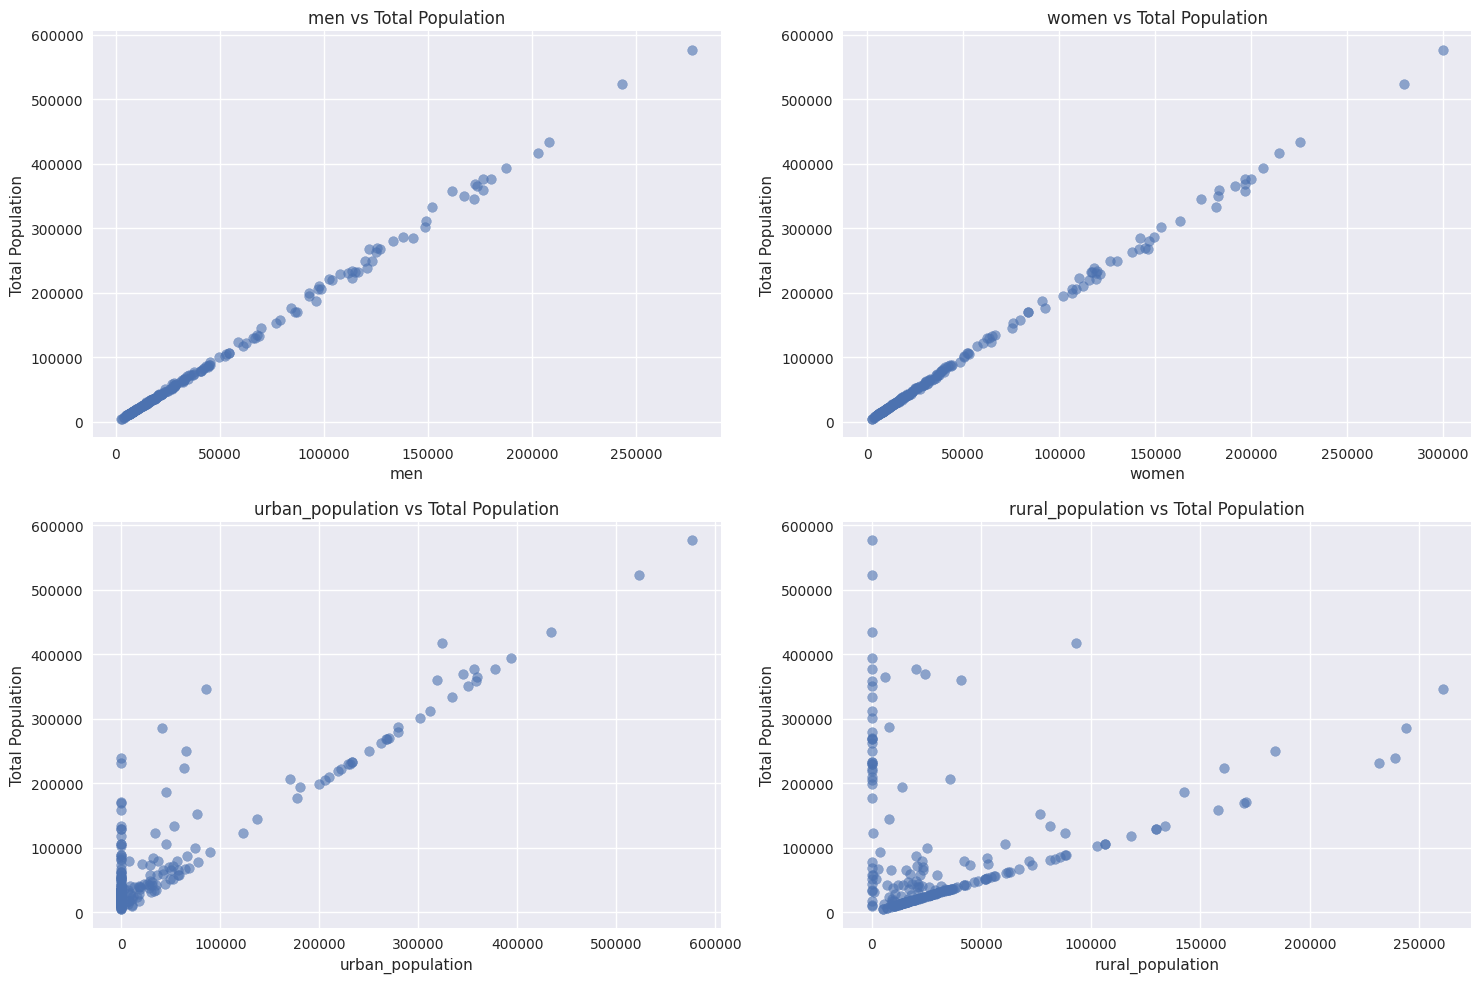


Size of training set: (181, 4)
Size of test set: (46, 4)


In [ ]:
# Visualations scatter plots among the target property and general variable
features = ['men', 'women', 'urban_population', 'rural_population']
target = 'Total_population'

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    plt.scatter(df_clean[feature], df_clean[target], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel('Total Population')
    plt.title(f'{feature} vs Total Population')
plt.tight_layout()
plt.show()

# 3. Data Preparation
X = df_clean[features]  # Properties
y = df_clean[target]    # Target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nSize of training set: {X_train.shape}")
print(f"Size of test set: {X_test.shape}")


In [ ]:
# 4. Building and Training the Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("\nCoefficient model:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")



Coefficient model:
men: 0.50
women: 0.50
urban_population: 0.50
rural_population: 0.50
Intercept: -0.00


In [ ]:
# 5. Making Predictions on the Test Set
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 6. Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel grade:")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"R² Score: {r2:.2f}")



Model grade:
MSE (Mean Squared Error): 0.00
R² Score: 1.00


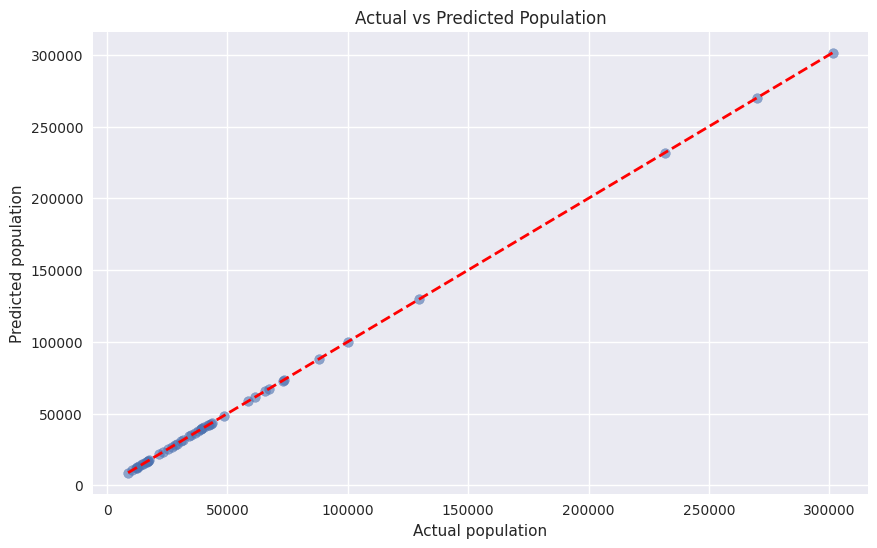

In [ ]:
# 7. Visualizing the Results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual population')
plt.ylabel('Predicted population')
plt.title('Actual vs Predicted Population')
plt.show()


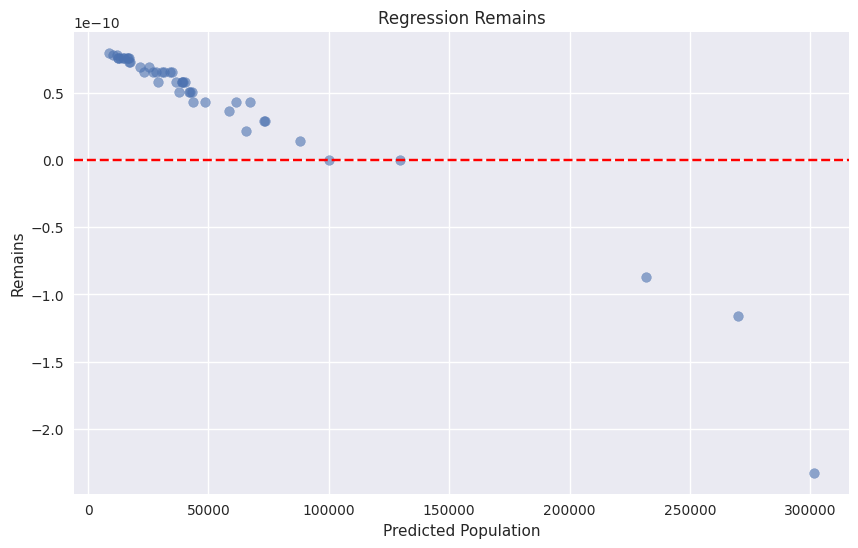

In [ ]:
# Additionally: Remains of Regression
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Population')
plt.ylabel('Remains')
plt.title('Regression Remains')
plt.show()

Midterm:

In [ ]:
# ===== 1. DATA PREPARATION =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import os

# Load the dataset
path = "/root/.cache/kagglehub/datasets/nurasssyl/kazakhstan-population-by-gender-and-locality-2024/versions/2"
file_path = os.path.join(path, "Population of the Republic of Kazakhstan by gender and type of locality (as of July 1 2024).csv")
df = pd.read_csv(file_path)

# Data cleaning
df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].str.replace(",", "").astype(int)

print("First 5 rows of the cleaned data:")
print(df_clean.head())


First 5 rows of the cleaned data:
  Districts (adm2 level)  Total population     men   women  urban_population  \
0             Semei с.а.            311694  149017  162677            311604   
1         Кurchatov с.а.             10217    4987    5230             10217   
2          Abai district             13756    6906    6850                 0   
3        Aksuat district             19128    9826    9302                 0   
4         Ayagoz distict             64968   32699   32269             41820   

   urban_population_men  urban_population_women  rural_population  \
0                148967                  162637                90   
1                  4987                    5230                 0   
2                     0                       0             13756   
3                     0                       0             19128   
4                 20717                   21103             23148   

   rural_population_men  rural_population_women  
0                   

In [ ]:
# ===== 2. SUPERVISED LEARNING =====

# 2.1. Create a binary target variable
# Label: if a district's population is greater than 100,000 → large district (1), otherwise small (0)
df_clean['large_district'] = (df_clean['Total population'] > 100000).astype(int)

# 2.2. Define features and target variable
# Using features: men, women, urban population, rural population
X = df_clean[['men', 'women', 'urban_population', 'rural_population']]
y = df_clean['large_district']

print(f"Shape of X: {X.shape}")
print(f"Distribution of the target variable:\n{y.value_counts()}")


Shape of X: (227, 4)
Distribution of the target variable:
large_district
0    170
1     57
Name: count, dtype: int64


In [ ]:
# 2.3. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (158, 4)
Test set: (69, 4)


In [ ]:
# 2.4. Train a Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2.5. Evaluate model accuracy
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("=== DECISION TREE MODEL EVALUATION ===")
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== DECISION TREE MODEL EVALUATION ===
Accuracy: 0.986

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        52
           1       0.94      1.00      0.97        17

    accuracy                           0.99        69
   macro avg       0.97      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



In [ ]:
# 2.6. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={'size': 12},
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    xticklabels=['Small district', 'Large district'],
    yticklabels=['Small district', 'Large district']
)
plt.ylabel('Actual values')
plt.xlabel('Predicted values')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
finalize_figure('figure_8_confusion_matrix.png')


In [ ]:
# ===== 3. UNSUPERVISED LEARNING =====

# 3.1. Select 2 features for clustering
# Using urban and rural population to cluster districts
X_cluster = df_clean[['urban_population', 'rural_population']]

print("Selected features for clustering:")
print(X_cluster.head())


Selected features for clustering:
   urban_population  rural_population
0            311604                90
1             10217                 0
2                 0             13756
3                 0             19128
4             41820             23148


In [ ]:
# 3.2. Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Data after scaling:")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Standard deviation: {X_scaled.std(axis=0)}")


Data after scaling:
Mean: [-3.13014421e-17  3.52141224e-17]
Standard deviation: [1. 1.]


In [ ]:
# 3.3. Apply the K-Means algorithm
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print("Clustering results:")
print(f"Clusters: {np.unique(clusters)}")
print(f"Cluster sizes: {np.bincount(clusters)}")


Clustering results:
Clusters: [0 1 2]
Cluster sizes: [176  34  17]


In [ ]:
# Figure 9: elbow method
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10.5, 6.5))
plt.plot(k_range, wcss, marker='o', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
finalize_figure('figure_9_elbow_method.png')


In [ ]:
# 3.5. Re-cluster using the optimal K (e.g., K=3)
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans_optimal.fit_predict(X_scaled)

# 3.6. Add clusters to the main dataset
df_clean['Cluster'] = clusters

print("Data with clusters:")
print(df_clean[['Districts (adm2 level)', 'urban_population', 'rural_population', 'Cluster']].head())


Data with clusters:
  Districts (adm2 level)  urban_population  rural_population  Cluster
0             Semei с.а.            311604                90        1
1         Кurchatov с.а.             10217                 0        0
2          Abai district                 0             13756        0
3        Aksuat district                 0             19128        0
4         Ayagoz distict             41820             23148        0


In [ ]:
# Figure 10A: cluster visualization in PCA space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(kmeans_optimal.cluster_centers_)

plt.figure(figsize=(11, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', alpha=0.8, s=55)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=180, label='Centroids')
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(frameon=True)
finalize_figure('figure_10a_pca_clusters.png')


In [ ]:
# Figure 10B: cluster visualization in original feature space
plt.figure(figsize=(11, 8))
scatter = plt.scatter(
    df_clean['urban_population'],
    df_clean['rural_population'],
    c=df_clean['Cluster'],
    cmap='Set1',
    alpha=0.8,
    s=55
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Urban Population')
plt.ylabel('Rural Population')
finalize_figure('figure_10b_original_space_clusters.png')


In [ ]:
# Analyze cluster characteristics
cluster_analysis = df_clean.groupby('Cluster').agg({
    'urban_population': ['mean', 'std'],
    'rural_population': ['mean', 'std'],
    'Total population': 'mean',
    'Districts (adm2 level)': 'count'
}).round(2)

print("CLUSTER ANALYSIS:")
print(cluster_analysis)


CLUSTER ANALYSIS:
        urban_population           rural_population            \
                    mean       std             mean       std   
Cluster                                                         
0               12963.65  23815.34         25569.24  20252.92   
1              295563.18  93329.14          7111.38  18380.45   
2               17635.06  29535.82        163952.18  51613.38   

        Total population Districts (adm2 level)  
                    mean                  count  
Cluster                                          
0               38532.89                    176  
1              302674.56                     34  
2              181587.24                     17  


4.1. Key difference between supervised and unsupervised learning:
Supervised learning uses labeled data with known outcomes (targets) to train a predictive model.
Unsupervised learning works with unlabeled data, identifying hidden structures and patterns without predefined labels.

4.2. Factors influencing the choice of the number of clusters in K-Means:

Elbow method – analyzing the WCSS (Within-Cluster Sum of Squares) plot versus the number of clusters.

Domain knowledge and expert judgment – understanding the context of the data.

Data separation quality – measured by metrics like the silhouette coefficient.

Interpretability of results – ensuring clusters are meaningful and actionable.

4.3. Why PCA was used for cluster visualization:
PCA (Principal Component Analysis) is used to reduce data dimensionality and visualize high-dimensional data in 2D or 3D space.
This makes it possible to observe clusters even when the original data has more than two features.

***LAB WORK 5 - WORKING WITH DBSCAN***

In [ ]:
# Laboratory Work 5: DBSCAN Clustering on Kazakhstan Demographic Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import os

# Step 1: Load and prepare Kazakhstan demographic dataset
path = "/root/.cache/kagglehub/datasets/nurasssyl/kazakhstan-population-by-gender-and-locality-2024/versions/2"
file_path = os.path.join(path, "Population of the Republic of Kazakhstan by gender and type of locality (as of July 1 2024).csv")
df = pd.read_csv(file_path)

# preprocessing
df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].str.replace(",", "").astype(int)

# features for clustering
X = df_clean[['urban_population', 'rural_population', 'men', 'women']]

print("Dataset shape:", X.shape)
print("First 5 rows:")
print(X.head())

Dataset shape: (227, 4)
First 5 rows:
   urban_population  rural_population     men   women
0            311604                90  149017  162677
1             10217                 0    4987    5230
2                 0             13756    6906    6850
3                 0             19128    9826    9302
4             41820             23148   32699   32269


In [ ]:
# Step 2: Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data after scaling:")
print("Mean:", X_scaled.mean(axis=0))
print("Std:", X_scaled.std(axis=0))

Data after scaling:
Mean: [-3.13014421e-17  3.52141224e-17  0.00000000e+00 -3.13014421e-17]
Std: [1. 1. 1. 1.]


In [ ]:
# Step 3: Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.72260578 0.27708049]
Total variance explained: 0.9996862735560025


In [ ]:
# Step 4: DBSCAN with different parameter combinations
param_combinations = [
    {'eps': 0.5, 'min_samples': 3},
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 5},
    {'eps': 1.2, 'min_samples': 7},
    {'eps': 1.5, 'min_samples': 10}
]

results = []
for params in param_combinations:
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)

    # Calculate metrics only if we have more than 1 cluster
    if n_clusters > 1:
        sil_score = silhouette_score(X_scaled, labels)
        db_score = davies_bouldin_score(X_scaled, labels)
    else:
        sil_score = np.nan
        db_score = np.nan

    results.append({
        'params': params,
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette': sil_score,
        'davies_bouldin': db_score
    })

    print(f"eps={params['eps']}, min_samples={params['min_samples']}: "
          f"Clusters={n_clusters}, Noise={n_noise} ({noise_ratio:.1%})")

# Create results summary
results_df = pd.DataFrame([{
    'eps': r['params']['eps'],
    'min_samples': r['params']['min_samples'],
    'n_clusters': r['n_clusters'],
    'n_noise': r['n_noise'],
    'noise_ratio': r['noise_ratio'],
    'silhouette': r['silhouette'],
    'davies_bouldin': r['davies_bouldin']
} for r in results])

print("\nResults Summary:")
print(results_df.round(3))

eps=0.5, min_samples=3: Clusters=4, Noise=13 (5.7%)
eps=0.8, min_samples=5: Clusters=2, Noise=8 (3.5%)
eps=1.0, min_samples=5: Clusters=1, Noise=7 (3.1%)
eps=1.2, min_samples=7: Clusters=1, Noise=8 (3.5%)
eps=1.5, min_samples=10: Clusters=1, Noise=6 (2.6%)

Results Summary:
   eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette  \
0  0.5            3           4       13        0.057       0.493   
1  0.8            5           2        8        0.035       0.711   
2  1.0            5           1        7        0.031         NaN   
3  1.2            7           1        8        0.035         NaN   
4  1.5           10           1        6        0.026         NaN   

   davies_bouldin  
0           1.136  
1           1.034  
2             NaN  
3             NaN  
4             NaN  


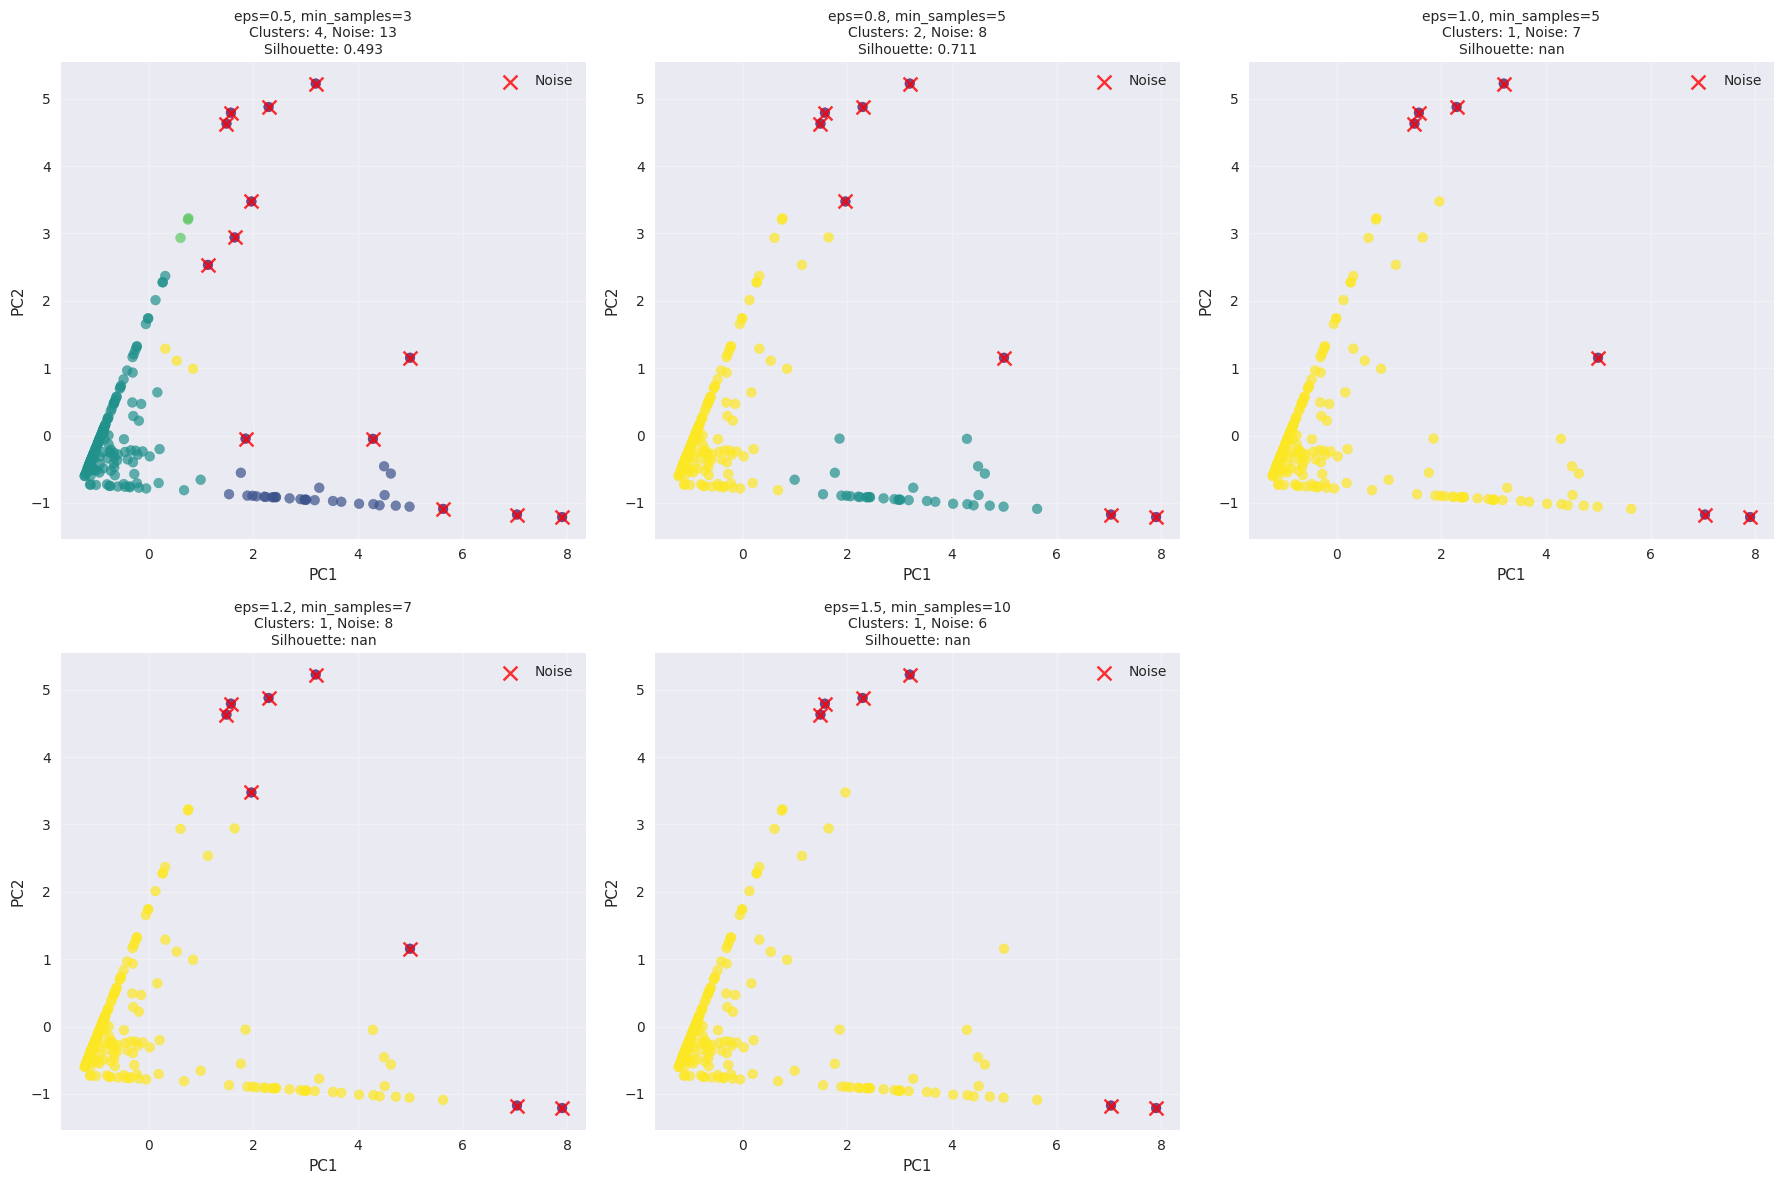

In [ ]:
# 5: Visualize DBSCAN results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (result, ax) in enumerate(zip(results, axes)):
    labels = result['labels']
    params = result['params']

    # Create scatter plot
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                        c=labels, cmap='viridis', alpha=0.7, s=50)

    # this highlight noise points with color red
    noise_mask = (labels == -1)
    if any(noise_mask):
        ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                  c='red', marker='x', s=100, label='Noise', alpha=0.8)

    ax.set_title(f"eps={params['eps']}, min_samples={params['min_samples']}\n"
                f"Clusters: {result['n_clusters']}, Noise: {result['n_noise']}\n"
                f"Silhouette: {result['silhouette']:.3f}", fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove the last empty plot
for i in range(len(results), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

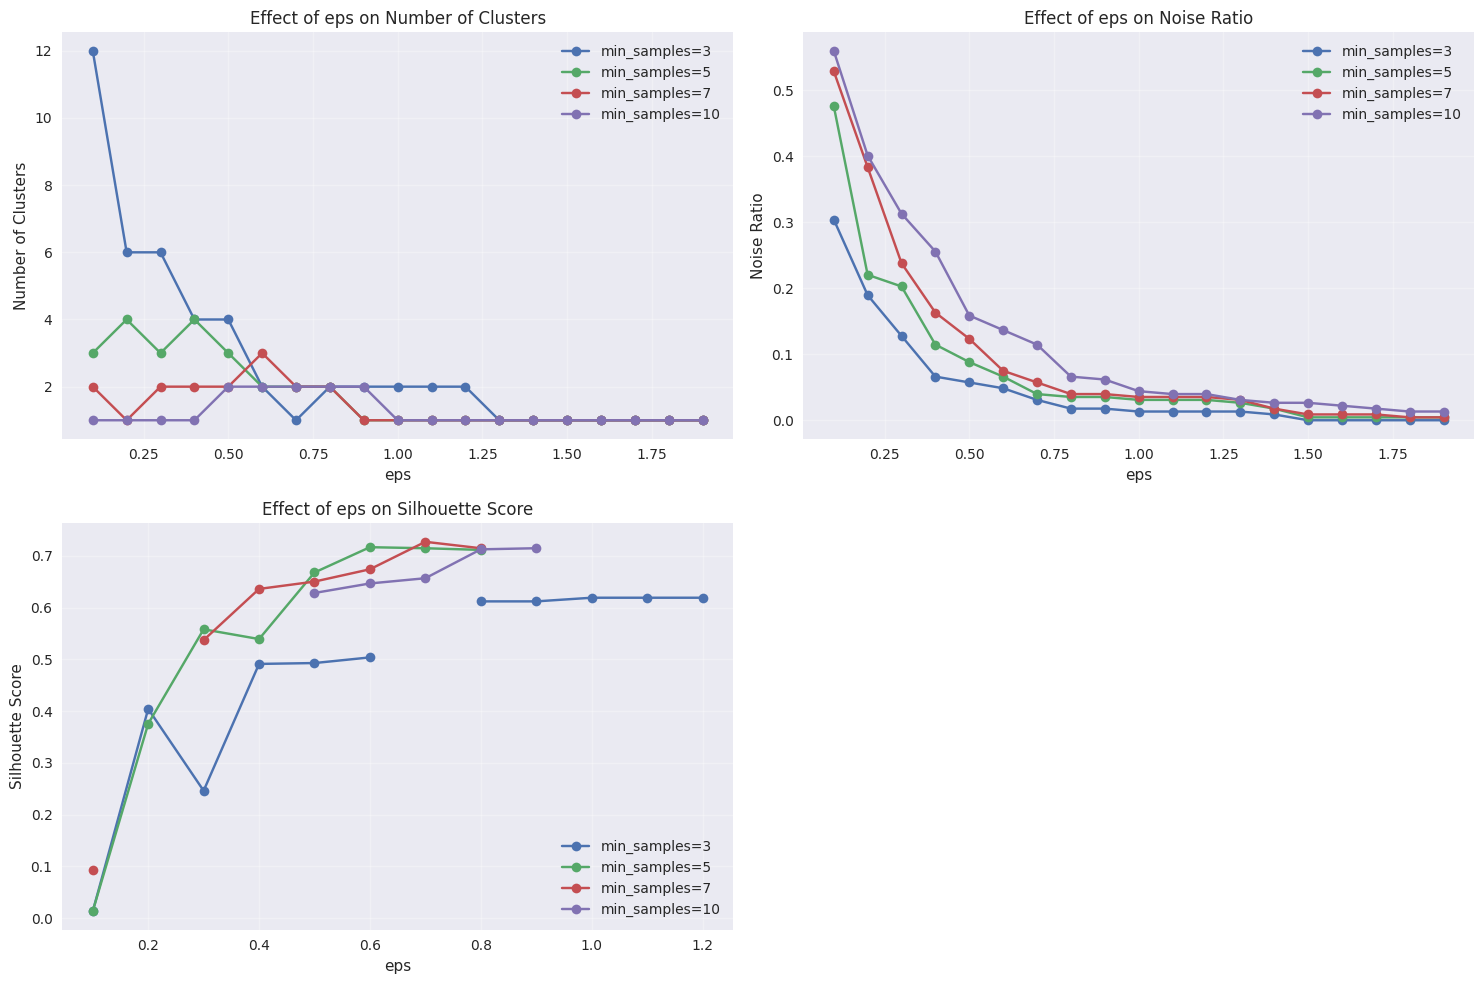

In [ ]:
# 6: Analyze eps parameter influence
eps_values = np.arange(0.1, 2.0, 0.1)
min_samples_values = [3, 5, 7, 10]

plt.figure(figsize=(15, 10))

# Plot 1: eps vs number of clusters
plt.subplot(2, 2, 1)
for min_samples in min_samples_values:
    n_clusters_list = []
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_clusters_list.append(n_clusters)

    plt.plot(eps_values, n_clusters_list, 'o-', label=f'min_samples={min_samples}')

plt.xlabel('eps')
plt.ylabel('Number of Clusters')
plt.title('Effect of eps on Number of Clusters')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: eps vs noise ratio
plt.subplot(2, 2, 2)
for min_samples in min_samples_values:
    noise_ratios = []
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_noise = list(labels).count(-1)
        noise_ratios.append(n_noise / len(labels))

    plt.plot(eps_values, noise_ratios, 'o-', label=f'min_samples={min_samples}')

plt.xlabel('eps')
plt.ylabel('Noise Ratio')
plt.title('Effect of eps on Noise Ratio')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: eps vs silhouette score
plt.subplot(2, 2, 3)
for min_samples in min_samples_values:
    sil_scores = []
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            sil_score = silhouette_score(X_scaled, labels)
        else:
            sil_score = np.nan
        sil_scores.append(sil_score)

    plt.plot(eps_values, sil_scores, 'o-', label=f'min_samples={min_samples}')

plt.xlabel('eps')
plt.ylabel('Silhouette Score')
plt.title('Effect of eps on Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Optimal DBSCAN parameters:
eps: 0.8
min_samples: 5
Number of clusters: 2
Silhouette score: 0.711
Noise ratio: 3.5%


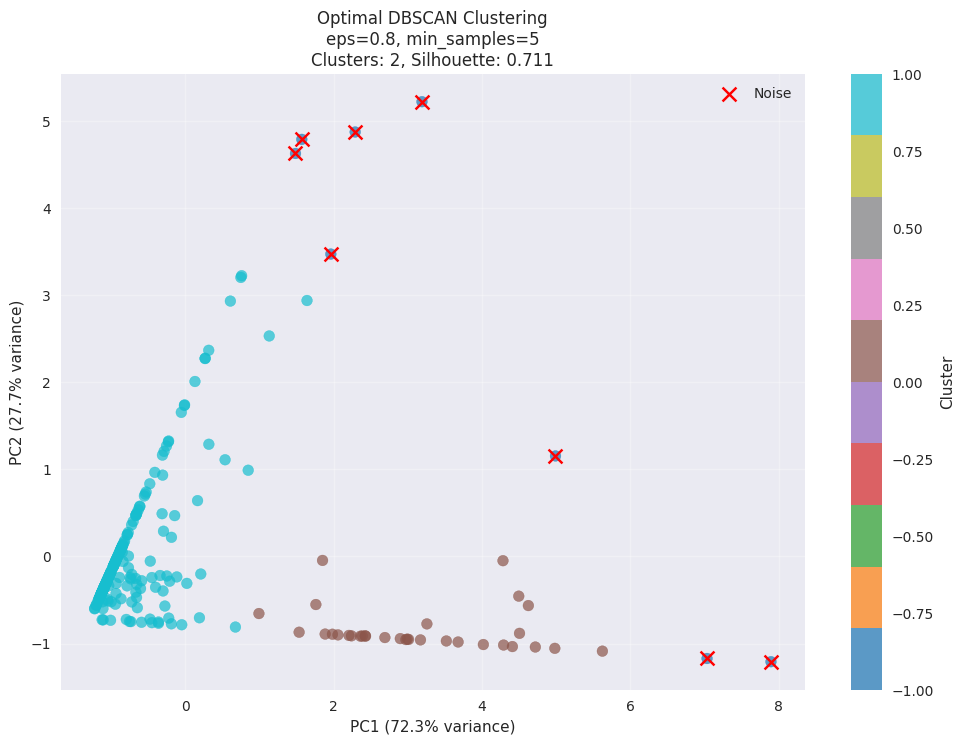

In [ ]:
# 7: Compare with optimal parameters
optimal_result = max([r for r in results if not np.isnan(r['silhouette'])],
                    key=lambda x: x['silhouette'])

print("Optimal DBSCAN parameters:")
print(f"eps: {optimal_result['params']['eps']}")
print(f"min_samples: {optimal_result['params']['min_samples']}")
print(f"Number of clusters: {optimal_result['n_clusters']}")
print(f"Silhouette score: {optimal_result['silhouette']:.3f}")
print(f"Noise ratio: {optimal_result['noise_ratio']:.1%}")

# Visualize optimal clustering
optimal_labels = optimal_result['labels']

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=optimal_labels, cmap='tab10', alpha=0.7, s=60)

# Highlight noise
noise_mask = (optimal_labels == -1)
if any(noise_mask):
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='red', marker='x', s=100, label='Noise')

plt.colorbar(scatter, label='Cluster')
plt.title(f'Optimal DBSCAN Clustering\n'
         f'eps={optimal_result["params"]["eps"]}, '
         f'min_samples={optimal_result["params"]["min_samples"]}\n'
         f'Clusters: {optimal_result["n_clusters"]}, '
         f'Silhouette: {optimal_result["silhouette"]:.3f}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 8: Cluster analysis and interpretation
optimal_labels = optimal_result['labels']
df_clean['dbscan_cluster'] = optimal_labels

# Analyze cluster characteristics
cluster_analysis = df_clean.groupby('dbscan_cluster').agg({
    'urban_population': ['mean', 'std', 'min', 'max'],
    'rural_population': ['mean', 'std', 'min', 'max'],
    'men': 'mean',
    'women': 'mean',
    'Total population': 'mean',
    'Districts (adm2 level)': 'count'
}).round(0)

print("Cluster Characteristics:")
print(cluster_analysis)

# Interpretation of clusters
print("\nCluster Interpretation:")
for cluster_id in sorted(df_clean['dbscan_cluster'].unique()):
    cluster_data = df_clean[df_clean['dbscan_cluster'] == cluster_id]
    if cluster_id == -1:
        print(f"Noise points ({len(cluster_data)} districts): Various characteristics")
    else:
        avg_urban = cluster_data['urban_population'].mean()
        avg_rural = cluster_data['rural_population'].mean()
        print(f"Cluster {cluster_id} ({len(cluster_data)} districts): "
              f"Urban avg: {avg_urban:.0f}, Rural avg: {avg_rural:.0f}")

Cluster Characteristics:
               urban_population                           rural_population  \
                           mean       std     min     max             mean   
dbscan_cluster                                                               
-1                     201985.0  238377.0       0  576517         156478.0   
 0                     273835.0   73181.0  137114  433788           4891.0   
 1                      12043.0   21857.0       0  122684          32732.0   

                                           men     women Total population  \
                     std min     max      mean      mean             mean   
dbscan_cluster                                                              
-1              109946.0   0  260533  174606.0  183856.0         358462.0   
 0               10627.0   0   40632  132236.0  146490.0         278725.0   
 1               33935.0   0  170761   22564.0   22210.0          44774.0   

               Districts (adm2 level)  
   

***Laboratory Work 6: Support Vector Machines (SVM) and XGBoost***

In [ ]:
# ===== Laboratory Work 6: SVM and XGBoost on Kazakhstan Demographic Data =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import os

# Load and prepare Kazakhstan demographic dataset
path = "/root/.cache/kagglehub/datasets/nurasssyl/kazakhstan-population-by-gender-and-locality-2024/versions/2"
file_path = os.path.join(path, "Population of the Republic of Kazakhstan by gender and type of locality (as of July 1 2024).csv")
df = pd.read_csv(file_path)

# Data preprocessing
df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].str.replace(",", "").astype(int)

# Create target variable (urban vs rural districts)
df_clean["urban_ratio"] = df_clean["urban_population"] / df_clean["Total population"]
df_clean["target"] = (df_clean["urban_ratio"] > 0.5).astype(int)

# Prepare features and target
X = df_clean[["men", "women", "urban_population", "rural_population"]]
y = df_clean["target"]

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts())

Dataset shape: (227, 4)
Class distribution:
target
0    153
1     74
Name: count, dtype: int64


In [ ]:

# Dataset Preparation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Feature scaling applied successfully")

Training set size: (158, 4)
Test set size: (69, 4)
Feature scaling applied successfully


In [ ]:
# Implementing SVM with different kernels
svm_models = {
    'SVM Linear': SVC(kernel='linear', C=1.0, random_state=42),
    'SVM RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'SVM Polynomial': SVC(kernel='poly', degree=3, C=1.0, random_state=42)
}

svm_results = {}

for name, model in svm_models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    svm_results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy
    }

    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


SVM Linear Results:
Accuracy: 0.971

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        47
           1       0.95      0.95      0.95        22

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69

Confusion Matrix:
[[46  1]
 [ 1 21]]

SVM RBF Results:
Accuracy: 0.971

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.91      0.95        22

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.97        69
weighted avg       0.97      0.97      0.97        69

Confusion Matrix:
[[47  0]
 [ 2 20]]

SVM Polynomial Results:
Accuracy: 0.870

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00

In [ ]:
# Implementing XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train XGBoost model
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate XGBoost
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"Accuracy: {xgb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.971

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.91      0.95        22

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.97        69
weighted avg       0.97      0.97      0.97        69

Confusion Matrix:
[[47  0]
 [ 2 20]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:56:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/tmp/ipykernel_7174/560543901.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=features, palette='viridis')


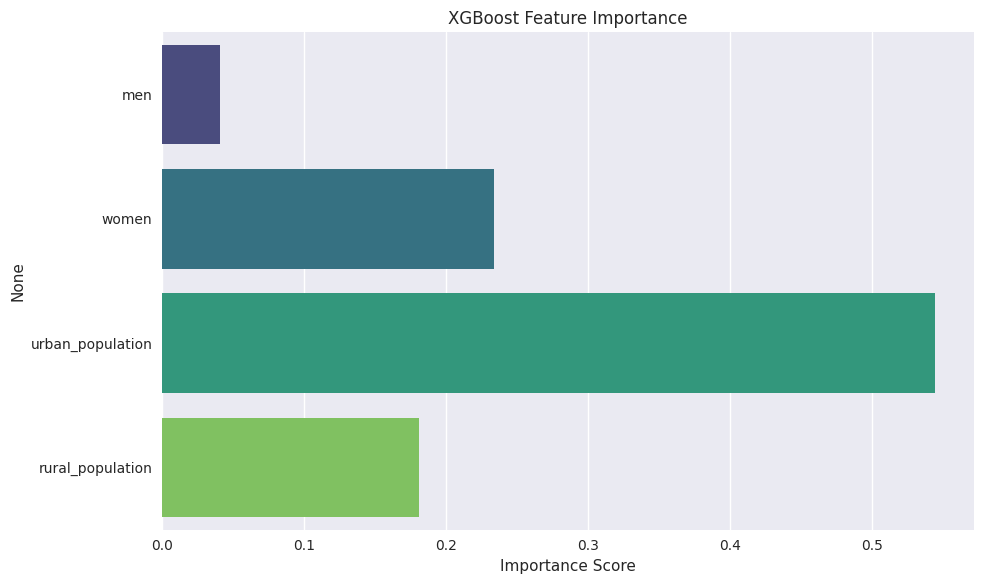

Feature Importance Scores:
men: 0.041
women: 0.234
urban_population: 0.545
rural_population: 0.181


In [ ]:
# Feature importance from XGBoost
feature_importance = xgb_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=features, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature Importance Scores:")
for feature, importance in zip(features, feature_importance):
    print(f"{feature}: {importance:.3f}")

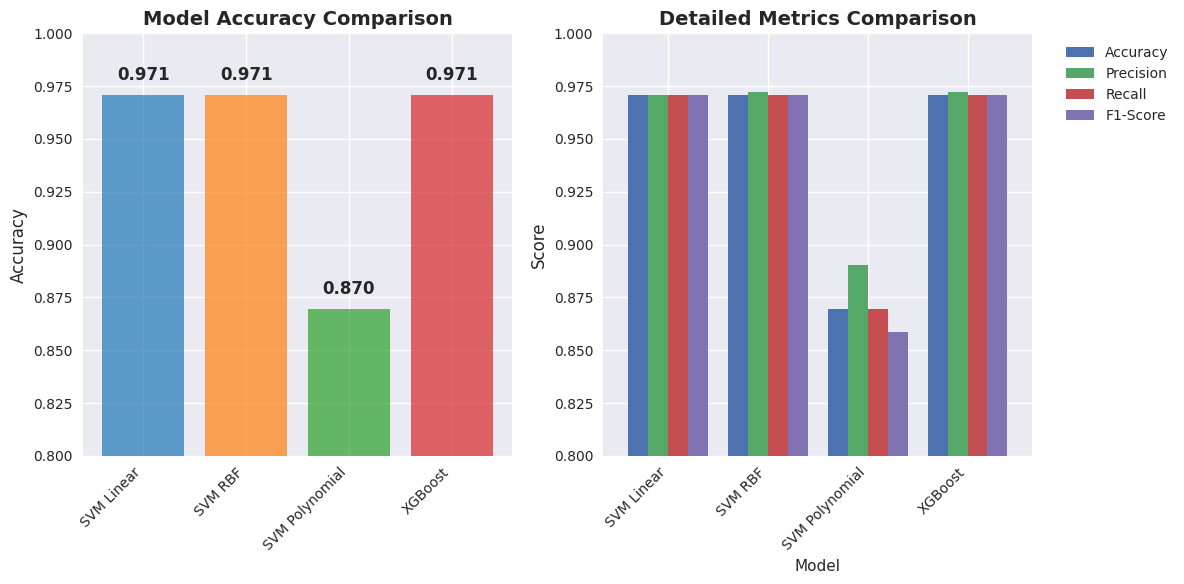


Detailed Comparison Table:
                Accuracy  Precision  Recall  F1-Score
Model                                                
SVM Linear         0.971      0.971   0.971     0.971
SVM RBF            0.971      0.972   0.971     0.971
SVM Polynomial     0.870      0.891   0.870     0.858
XGBoost            0.971      0.972   0.971     0.971


In [ ]:
# Model Comparison
models_comparison = {
    'SVM Linear': svm_results['SVM Linear']['accuracy'],
    'SVM RBF': svm_results['SVM RBF']['accuracy'],
    'SVM Polynomial': svm_results['SVM Polynomial']['accuracy'],
    'XGBoost': xgb_accuracy
}

# Visualization
plt.figure(figsize=(12, 6))

# Bar plot comparison
plt.subplot(1, 2, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(models_comparison.keys(), models_comparison.values(), color=colors, alpha=0.7)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)

# Add value labels on bars
for bar, value in zip(bars, models_comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Detailed metrics comparison
plt.subplot(1, 2, 2)
metrics_data = []

for name in models_comparison.keys():
    if 'SVM' in name:
        y_pred = svm_results[name]['predictions']
    else:
        y_pred = y_pred_xgb

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df.set_index('Model', inplace=True)

# Plot metrics
metrics_df.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Detailed Metrics Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

print("\nDetailed Comparison Table:")
print(metrics_df.round(3))

SVM RBF with C=0.1: Accuracy = 0.870
SVM RBF with C=1.0: Accuracy = 0.971
SVM RBF with C=10.0: Accuracy = 0.971
SVM RBF with C=100.0: Accuracy = 0.971


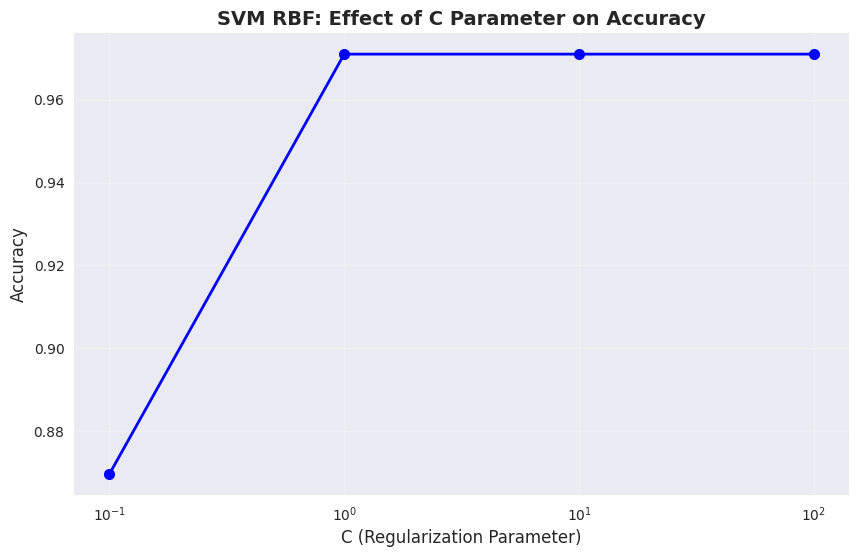

In [ ]:
# SVM Parameter Tuning Analysis
# Explore different C values for SVM RBF
c_values = [0.1, 1.0, 10.0, 100.0]
svm_c_results = []

for c in c_values:
    svm_temp = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    y_pred_temp = svm_temp.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred_temp)
    svm_c_results.append(accuracy)
    print(f"SVM RBF with C={c}: Accuracy = {accuracy:.3f}")

# Plot C parameter analysis
plt.figure(figsize=(10, 6))
plt.plot(c_values, svm_c_results, 'bo-', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM RBF: Effect of C Parameter on Accuracy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:56:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:56:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:56:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:56:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost with n_estimators=50: Accuracy = 0.971
XGBoost with n_estimators=100: Accuracy = 0.971
XGBoost with n_estimators=150: Accuracy = 0.971
XGBoost with n_estimators=200: Accuracy = 0.971


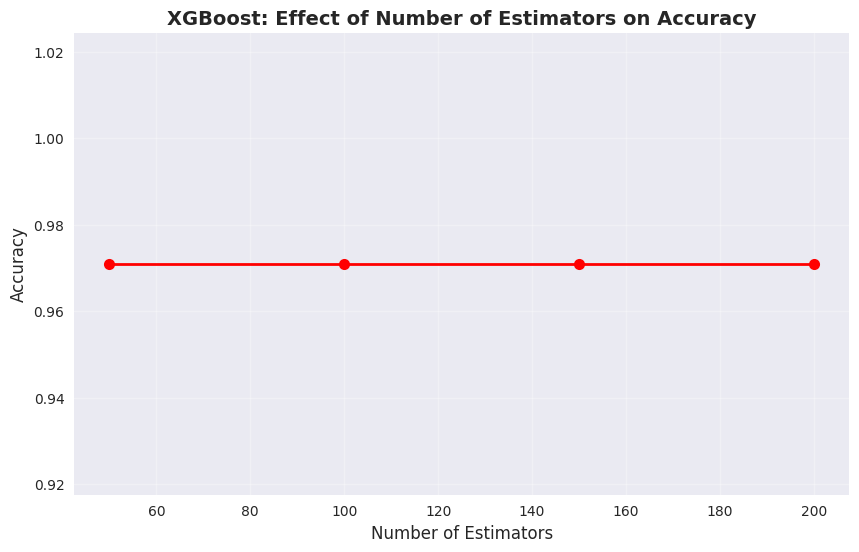

In [ ]:
# XGBoost Parameter Analysis
# Explore different numbers of estimators
n_estimators_values = [50, 100, 150, 200]
xgb_n_results = []

for n in n_estimators_values:
    xgb_temp = XGBClassifier(
        n_estimators=n,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    xgb_temp.fit(X_train, y_train)
    y_pred_temp = xgb_temp.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_temp)
    xgb_n_results.append(accuracy)
    print(f"XGBoost with n_estimators={n}: Accuracy = {accuracy:.3f}")

# Plot n_estimators analysis
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, xgb_n_results, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Estimators', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('XGBoost: Effect of Number of Estimators on Accuracy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# SVM with different kernels
svm_kernels = {
    'Linear': SVC(kernel='linear', C=1.0, random_state=42),
    'RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Polynomial': SVC(kernel='poly', degree=3, C=1.0, random_state=42)
}

svm_results = {}

print("SVM Classification with Different Kernels:")
print("=" * 50)

for kernel_name, model in svm_kernels.items():
    # Train SVM model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    svm_results[kernel_name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy
    }

    print(f"\n{kernel_name} Kernel SVM:")
    print(f"Accuracy: {accuracy:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

SVM Classification with Different Kernels:

Linear Kernel SVM:
Accuracy: 0.971
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        47
           1       0.95      0.95      0.95        22

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69


RBF Kernel SVM:
Accuracy: 0.971
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.91      0.95        22

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.97        69
weighted avg       0.97      0.97      0.97        69


Polynomial Kernel SVM:
Accuracy: 0.870
Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        47
           1    

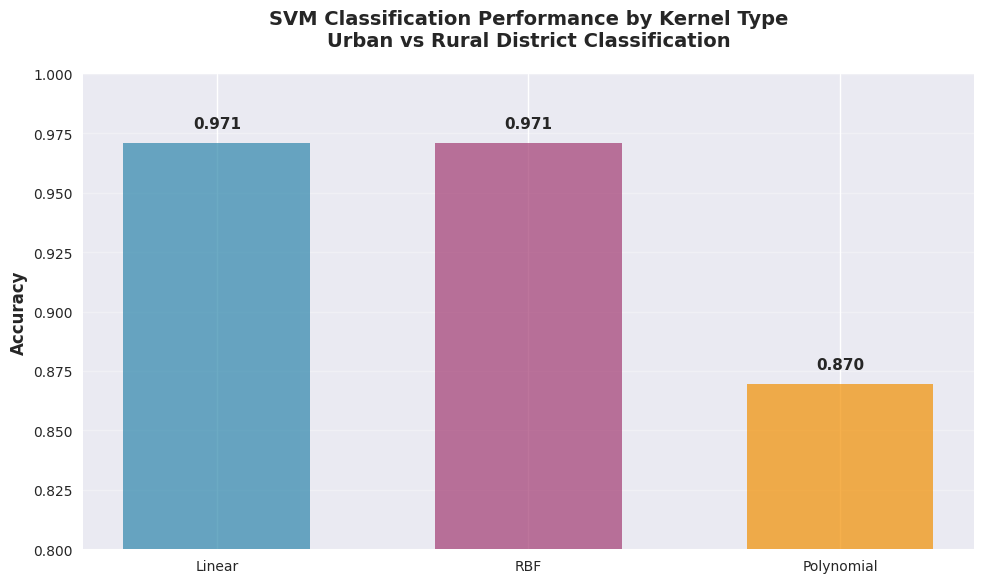


Best performing SVM kernel: Linear with 0.971 accuracy


In [ ]:
# Create SVM performance comparison plot
plt.figure(figsize=(10, 6))

kernels = list(svm_results.keys())
accuracies = [svm_results[kernel]['accuracy'] for kernel in kernels]
colors = ['#2E86AB', '#A23B72', '#F18F01']

bars = plt.bar(kernels, accuracies, color=colors, alpha=0.7, width=0.6)
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('SVM Classification Performance by Kernel Type\nUrban vs Rural District Classification',
          fontsize=14, fontweight='bold', pad=20)
plt.ylim(0.8, 1.0)

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Best performing kernel
best_kernel = kernels[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"\nBest performing SVM kernel: {best_kernel} with {best_accuracy:.3f} accuracy")

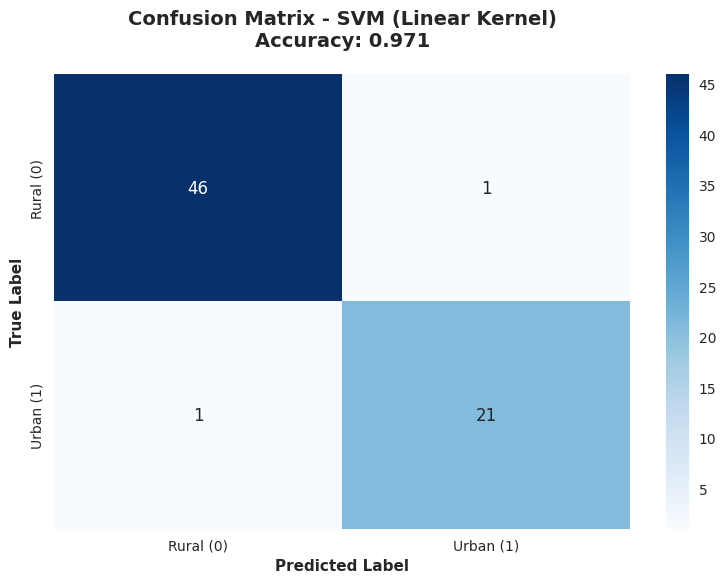

Confusion Matrix Analysis:
True Negatives (Rural correctly classified): 46
False Positives (Rural misclassified as Urban): 1
False Negatives (Urban misclassified as Rural): 1
True Positives (Urban correctly classified): 21


In [ ]:
# Confusion Matrix for Best SVM Model
best_svm_model = svm_results[best_kernel]['model']
y_pred_best = svm_results[best_kernel]['predictions']

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rural (0)', 'Urban (1)'],
            yticklabels=['Rural (0)', 'Urban (1)'])
plt.title(f'Confusion Matrix - SVM ({best_kernel} Kernel)\nAccuracy: {best_accuracy:.3f}',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

print("Confusion Matrix Analysis:")
print(f"True Negatives (Rural correctly classified): {cm[0,0]}")
print(f"False Positives (Rural misclassified as Urban): {cm[0,1]}")
print(f"False Negatives (Urban misclassified as Rural): {cm[1,0]}")
print(f"True Positives (Urban correctly classified): {cm[1,1]}")

SVM RBF Kernel - Effect of C Parameter:
C =   0.01: Accuracy = 0.681
C =   0.10: Accuracy = 0.870
C =   1.00: Accuracy = 0.971
C =  10.00: Accuracy = 0.971
C = 100.00: Accuracy = 0.971


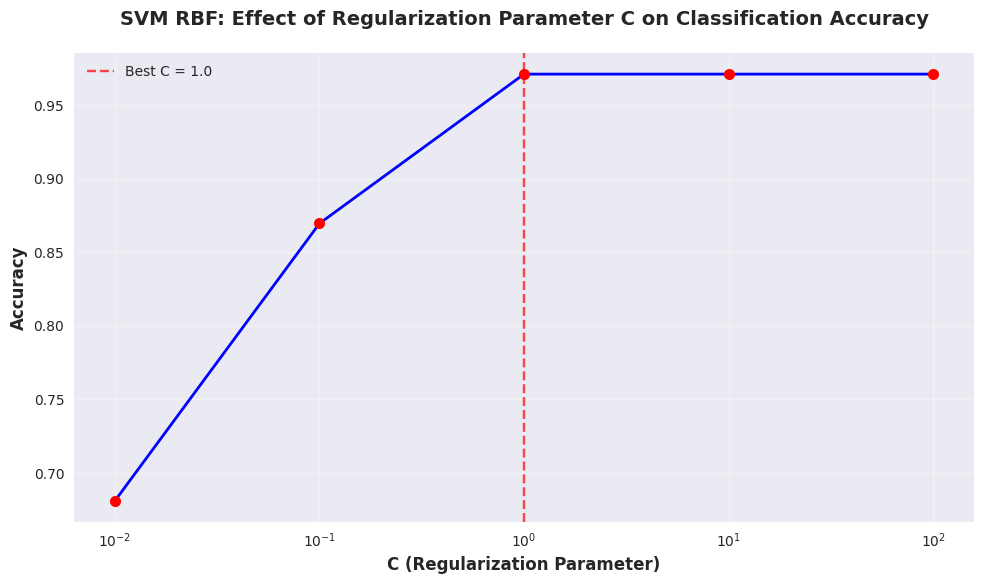

In [ ]:
# SVM Parameter Analysis - Effect of C parameter
c_values = [0.01, 0.1, 1.0, 10.0, 100.0]
c_accuracies = []

print("SVM RBF Kernel - Effect of C Parameter:")
print("=" * 40)

for c_val in c_values:
    svm_temp = SVC(kernel='rbf', C=c_val, gamma='scale', random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    y_pred_temp = svm_temp.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred_temp)
    c_accuracies.append(accuracy)
    print(f"C = {c_val:6.2f}: Accuracy = {accuracy:.3f}")

# Plot C parameter analysis
plt.figure(figsize=(10, 6))
plt.plot(c_values, c_accuracies, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('SVM RBF: Effect of Regularization Parameter C on Classification Accuracy',
          fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)

# Highlight best C value
best_c_index = np.argmax(c_accuracies)
plt.axvline(x=c_values[best_c_index], color='red', linestyle='--', alpha=0.7,
            label=f'Best C = {c_values[best_c_index]}')
plt.legend()

plt.tight_layout()
plt.show()

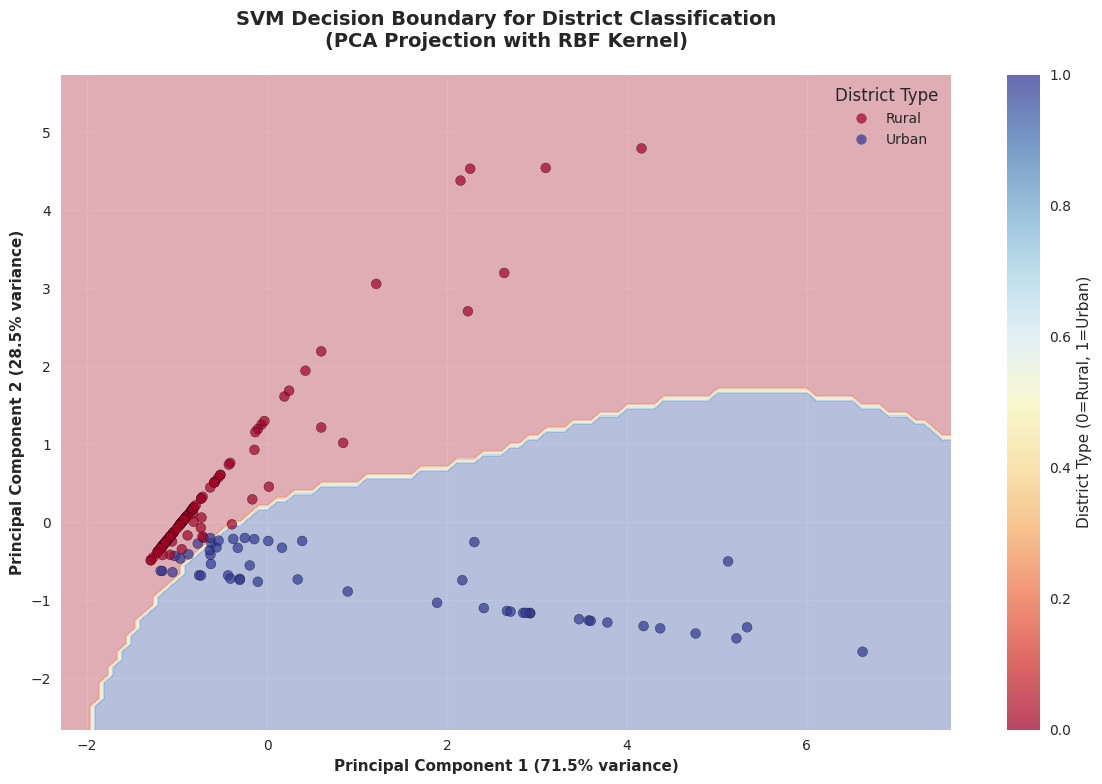

PCA Explained Variance: 100.0%


In [ ]:
# Decision Boundary Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Train SVM on PCA-transformed data for visualization
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_pca.fit(X_pca, y_train)

# Create mesh grid for decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on mesh grid
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='RdYlBu',
                      edgecolors='k', s=50, alpha=0.7)

plt.colorbar(scatter, label='District Type (0=Rural, 1=Urban)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
           fontweight='bold')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
           fontweight='bold')
plt.title('SVM Decision Boundary for District Classification\n(PCA Projection with RBF Kernel)',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Rural', 'Urban'],
           title="District Type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA Explained Variance: {pca.explained_variance_ratio_.sum():.1%}")


**Laboratory Work 7: t-Distributed Stochastic Neighbor
Embedding (t-SNE) and PCA Comparison ** **`*`Текст, выделенный полужирным шрифтом`*`**

In [ ]:
# ===== Laboratory Work 7: t-SNE and PCA Comparison on Kazakhstan Demographic Data =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import time
import os

# Load and prepare Kazakhstan demographic dataset
path = "/root/.cache/kagglehub/datasets/nurasssyl/kazakhstan-population-by-gender-and-locality-2024/versions/2"
file_path = os.path.join(path, "Population of the Republic of Kazakhstan by gender and type of locality (as of July 1 2024).csv")
df = pd.read_csv(file_path)

# Data preprocessing
df_clean = df.replace("-", "0")
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].str.replace(",", "").astype(int)

# Create target variable for visualization
df_clean["urban_ratio"] = df_clean["urban_population"] / df_clean["Total population"]
df_clean["district_type"] = (df_clean["urban_ratio"] > 0.5).astype(int)

# Prepare features for dimensionality reduction
features = ["men", "women", "urban_population", "rural_population", "urban_population_men",
            "urban_population_women", "rural_population_men", "rural_population_women"]
X = df_clean[features]
y = df_clean["district_type"]

print("Dataset Information:")
print(f"Shape: {X.shape}")
print(f"Features: {features}")
print(f"Urban districts: {sum(y)}, Rural districts: {len(y)-sum(y)}")

Dataset Information:
Shape: (227, 8)
Features: ['men', 'women', 'urban_population', 'rural_population', 'urban_population_men', 'urban_population_women', 'rural_population_men', 'rural_population_women']
Urban districts: 74, Rural districts: 153


In [ ]:
# Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully")
print(f"Scaled data shape: {X_scaled.shape}")

Data scaled successfully
Scaled data shape: (227, 8)


Applying PCA...
PCA completed in 0.00 seconds
Explained variance ratio: [0.60322463 0.39640404]
Total explained variance: 1.000


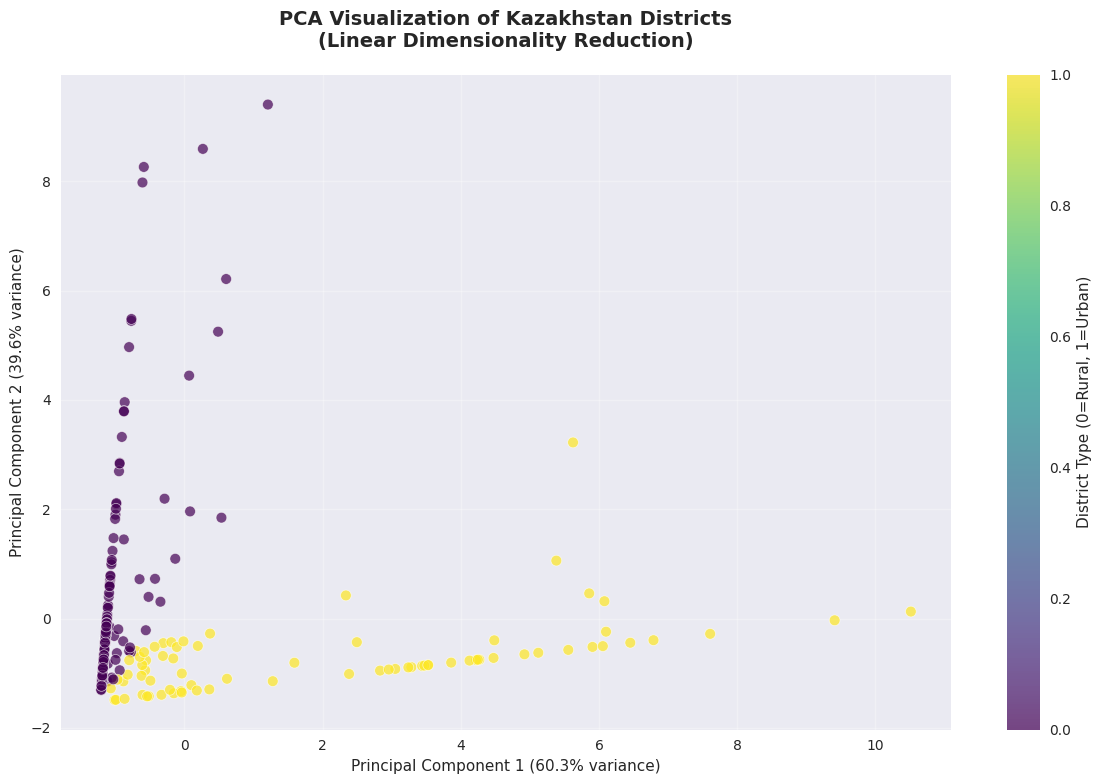

In [ ]:
# ===== 4. Applying PCA =====
print("Applying PCA...")
start_time = time.time()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_time = time.time() - start_time

print(f"PCA completed in {pca_time:.2f} seconds")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.3f}")

# PCA Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                      alpha=0.7, s=60, edgecolors='w', linewidth=0.5)
plt.colorbar(scatter, label='District Type (0=Rural, 1=Urban)')
plt.title('PCA Visualization of Kazakhstan Districts\n(Linear Dimensionality Reduction)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Applying t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed in 0.97 seconds


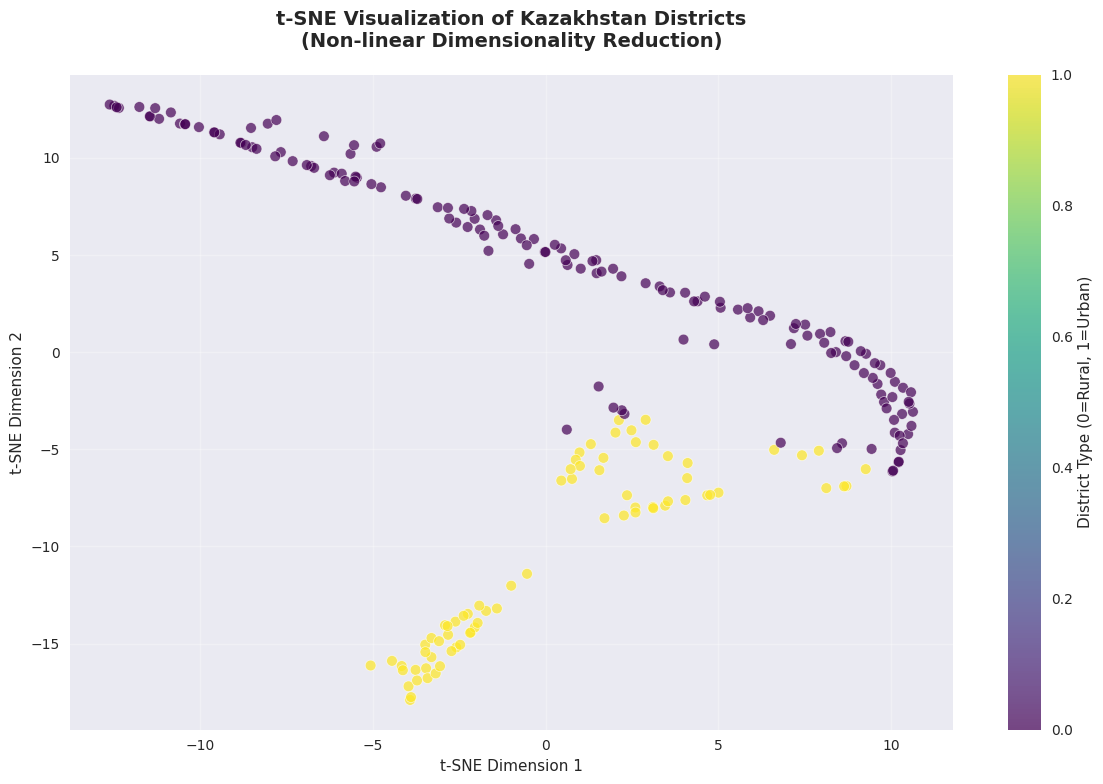

In [ ]:
# ===== 5. Applying t-SNE =====
print("Applying t-SNE...")
start_time = time.time()

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=42, learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

tsne_time = time.time() - start_time

print(f"t-SNE completed in {tsne_time:.2f} seconds")

# t-SNE Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis',
                      alpha=0.7, s=60, edgecolors='w', linewidth=0.5)
plt.colorbar(scatter, label='District Type (0=Rural, 1=Urban)')
plt.title('t-SNE Visualization of Kazakhstan Districts\n(Non-linear Dimensionality Reduction)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

t-SNE Parameter Exploration (Perplexity):


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


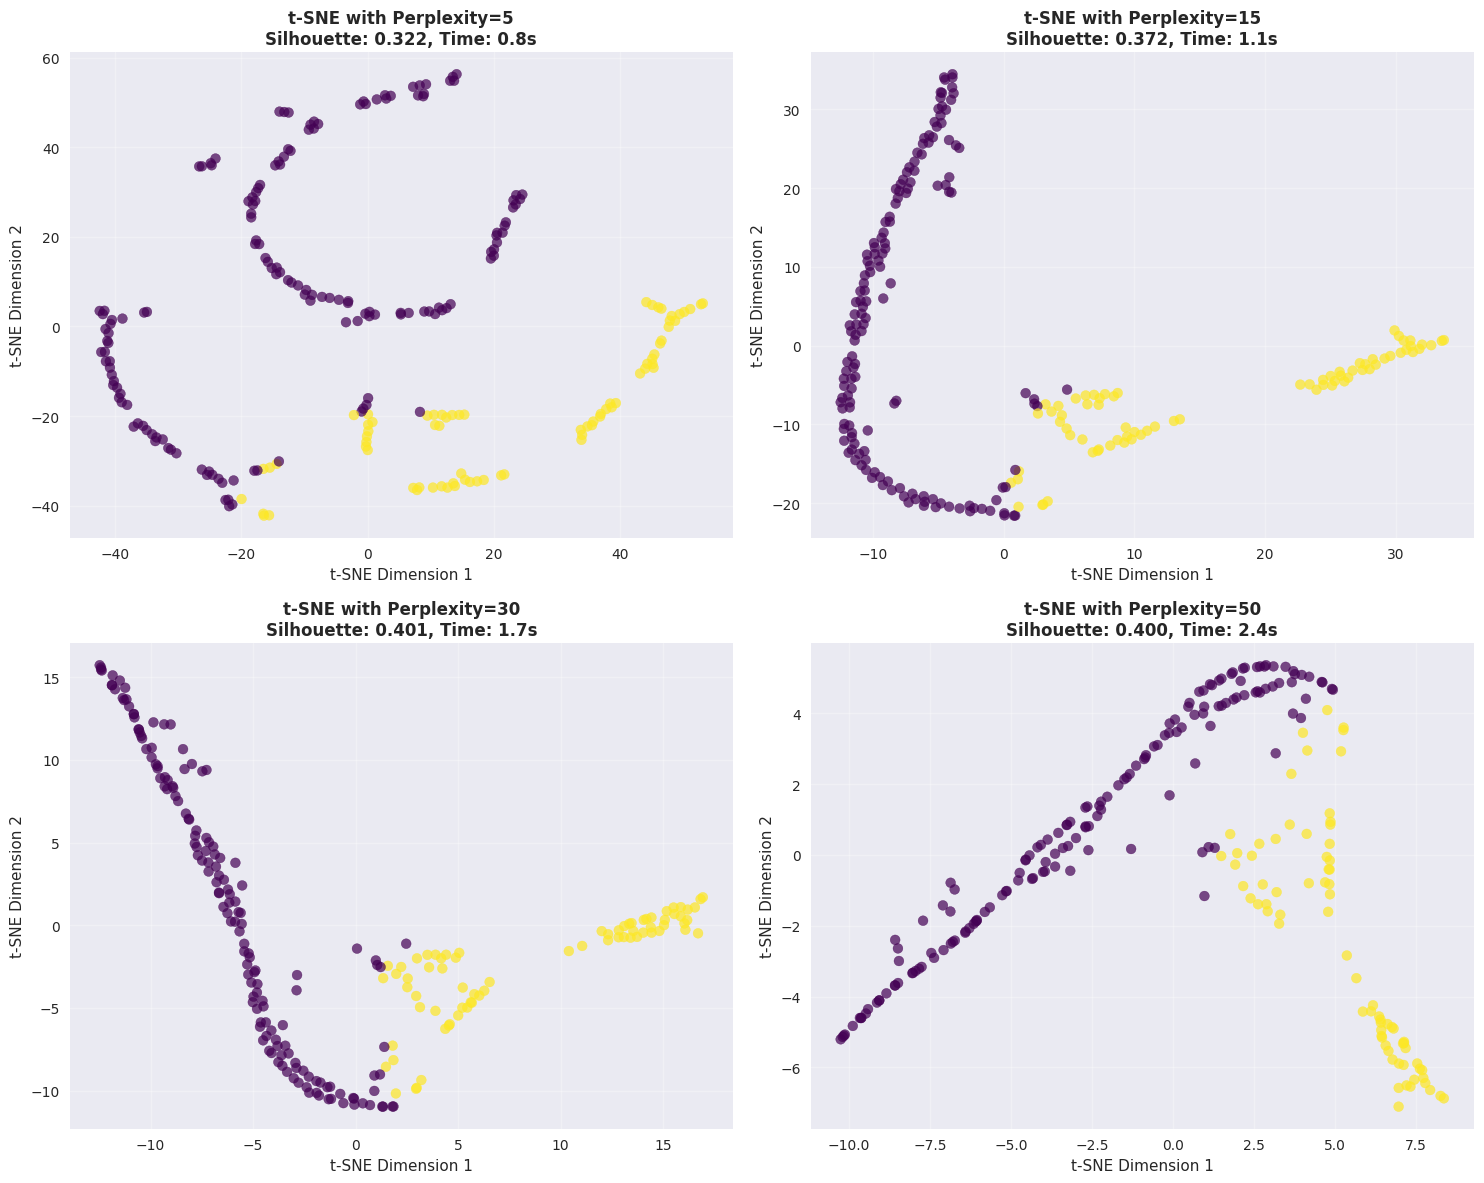


Perplexity Analysis:
Lower perplexity: Focuses on local structure, may create more small clusters
Higher perplexity: Considers more global structure, smoother clusters


In [ ]:
# ===== 6. Parameter Exploration (t-SNE) =====
perplexity_values = [5, 15, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

print("t-SNE Parameter Exploration (Perplexity):")
print("=" * 50)

for i, perplexity in enumerate(perplexity_values):
    start_time = time.time()

    tsne_temp = TSNE(n_components=2, perplexity=perplexity,
                     n_iter=1000, random_state=42)
    X_tsne_temp = tsne_temp.fit_transform(X_scaled)

    computation_time = time.time() - start_time

    # Calculate silhouette score for cluster separation quality
    sil_score = silhouette_score(X_tsne_temp, y)

    # Plot
    scatter = axes[i].scatter(X_tsne_temp[:, 0], X_tsne_temp[:, 1],
                             c=y, cmap='viridis', alpha=0.7, s=50)
    axes[i].set_title(f't-SNE with Perplexity={perplexity}\nSilhouette: {sil_score:.3f}, Time: {computation_time:.1f}s',
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('t-SNE Dimension 1')
    axes[i].set_ylabel('t-SNE Dimension 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPerplexity Analysis:")
print("Lower perplexity: Focuses on local structure, may create more small clusters")
print("Higher perplexity: Considers more global structure, smoother clusters")

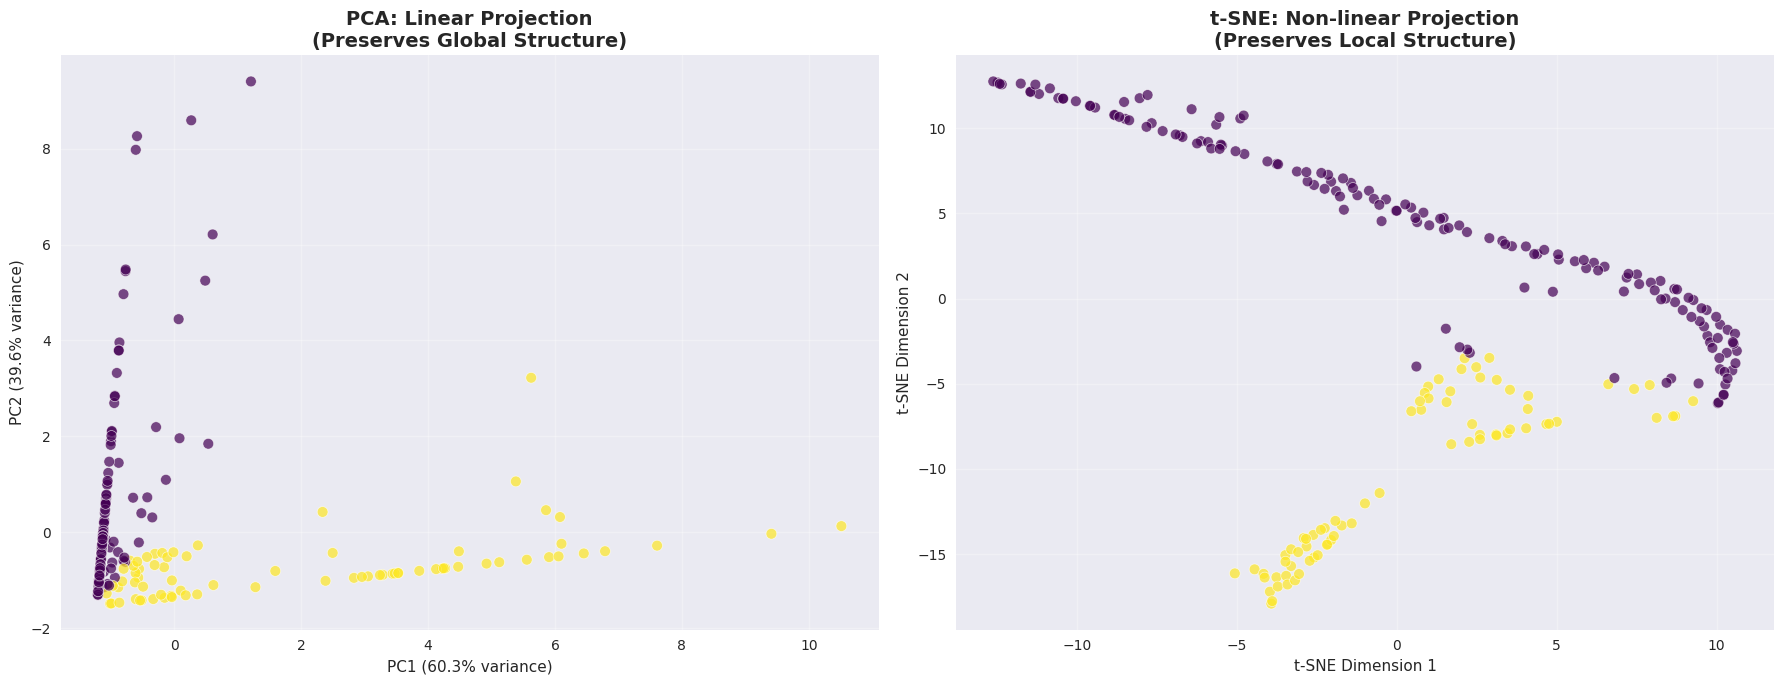

In [ ]:
# Comprehensive Comparison
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# PCA plot
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                      alpha=0.7, s=60, edgecolors='w', linewidth=0.5)
ax1.set_title('PCA: Linear Projection\n(Preserves Global Structure)',
             fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.grid(True, alpha=0.3)

# t-SNE plot
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis',
                      alpha=0.7, s=60, edgecolors='w', linewidth=0.5)
ax2.set_title('t-SNE: Non-linear Projection\n(Preserves Local Structure)',
             fontsize=14, fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
pca_silhouette = silhouette_score(X_pca, y)
tsne_silhouette = silhouette_score(X_tsne, y)

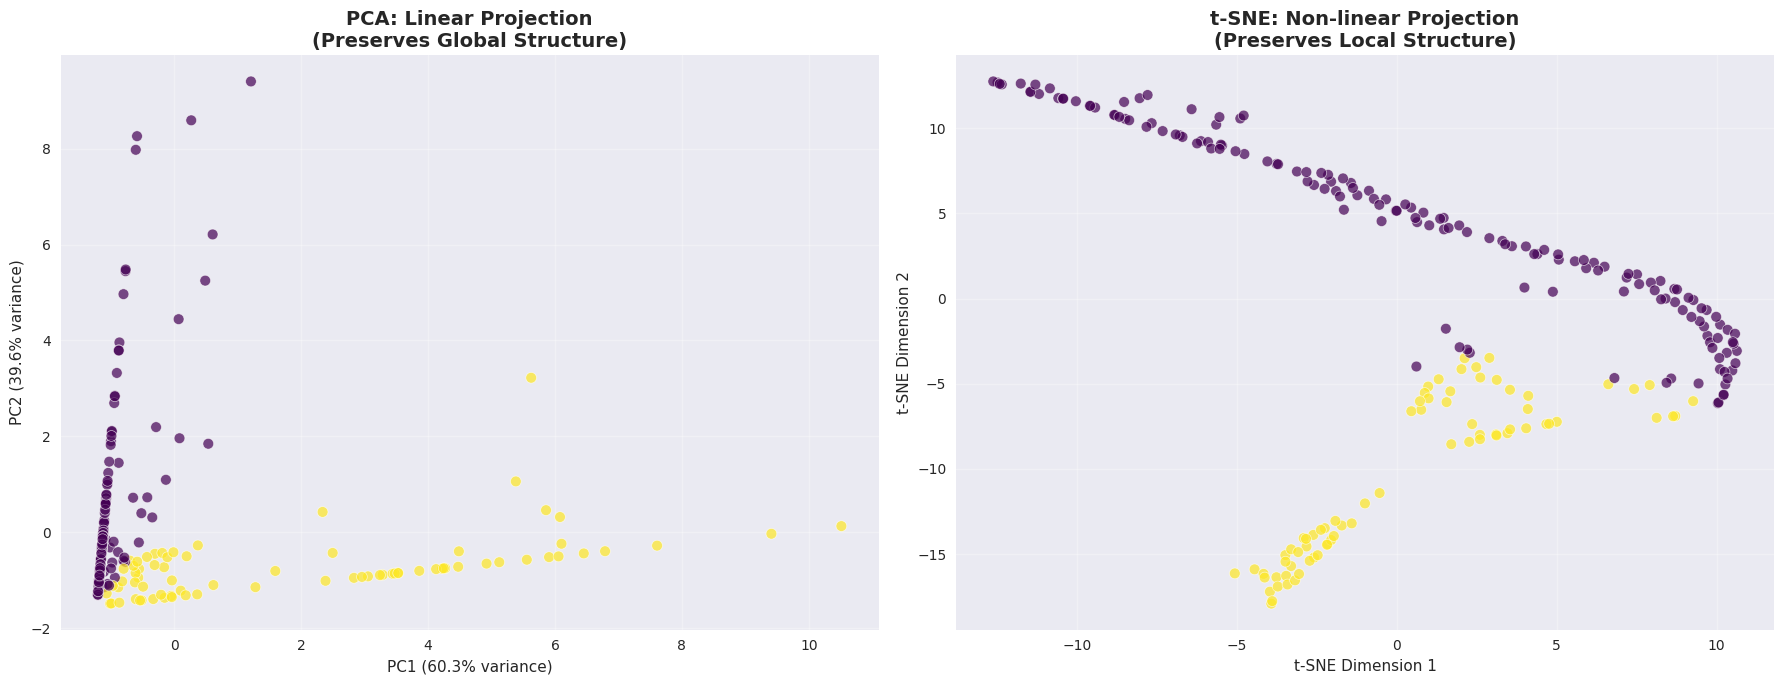

In [ ]:
# Comprehensive PCA and t-SNE comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# PCA visualization
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                      alpha=0.7, s=60, edgecolors='w', linewidth=0.5)
ax1.set_title('PCA: Linear Projection\n(Preserves Global Structure)',
             fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.grid(True, alpha=0.3)

# t-SNE visualization
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis',
                      alpha=0.7, s=60, edgecolors='w', linewidth=0.5)
ax2.set_title('t-SNE: Non-linear Projection\n(Preserves Local Structure)',
             fontsize=14, fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ===== 8. Advanced Analysis: Combined Approach =====
# Using PCA for initial reduction followed by t-SNE
print("Applying PCA + t-SNE pipeline...")

# First reduce to 10 components with PCA
pca_initial = PCA(n_components=10, random_state=42)
X_pca_reduced = pca_initial.fit_transform(X_scaled)

print(f"Variance retained by first 10 PCs: {sum(pca_initial.explained_variance_ratio_):.3f}")

# Then apply t-SNE to PCA-reduced data
start_time = time.time()
tsne_final = TSNE(n_components=2, perplexity=30, random_state=42)
X_pca_tsne = tsne_final.fit_transform(X_pca_reduced)
pipeline_time = time.time() - start_time

print(f"PCA+t-SNE pipeline completed in {pipeline_time:.2f} seconds")

# Compare all three approaches
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA only
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7, s=50)
axes[0].set_title(f'PCA Only\nTime: {pca_time:.1f}s', fontweight='bold')
axes[0].set_xlabel('PC1')

# t-SNE only
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.7, s=50)
axes[1].set_title(f't-SNE Only\nTime: {tsne_time:.1f}s', fontweight='bold')
axes[1].set_xlabel('t-SNE Dim1')

# PCA + t-SNE
scatter3 = axes[2].scatter(X_pca_tsne[:, 0], X_pca_tsne[:, 1], c=y, cmap='viridis', alpha=0.7, s=50)
axes[2].set_title(f'PCA + t-SNE\nTime: {pipeline_time:.1f}s', fontweight='bold')
axes[2].set_xlabel('t-SNE Dim1 (on PCA)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pipeline_silhouette = silhouette_score(X_pca_tsne, y)
print(f"Silhouette scores - PCA: {pca_silhouette:.3f}, t-SNE: {tsne_silhouette:.3f}, PCA+t-SNE: {pipeline_silhouette:.3f}")

Applying PCA + t-SNE pipeline...


ValueError: n_components=10 must be between 0 and min(n_samples, n_features)=8 with svd_solver='covariance_eigh'

In [ ]:
# ===== Feature Contribution Analysis =====
# Analyze which features contribute most to PCA components
pca_full = PCA(n_components=4, random_state=42)
pca_full.fit(X_scaled)

# Create feature importance heatmap
component_names = [f'PC{i+1}' for i in range(4)]
feature_importance = pd.DataFrame(
    pca_full.components_.T,
    index=features,
    columns=component_names
)

plt.figure(figsize=(12, 8))
sns.heatmap(feature_importance, annot=True, cmap='RdYlBu', center=0,
            fmt='.2f', linewidths=0.5)
plt.title('PCA Feature Loadings\n(Contribution of Original Features to Principal Components)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("PCA Component Interpretation:")
print("Positive loadings: Features that increase together in the component")
print("Negative loadings: Features that vary inversely in the component")